# Project: 멋진 챗봇 만들기 on Kaggle
    - Transformer 기반 한국어 챗봇 - Kaggle 환경

- 데이터 다운로드 : 송영숙 챗봇 데이터, ChatbotData.csv (Q, A, label)
- 정제 : 소문자화, 정규식 필터링
- 토큰화 : mecab.morphs 사용, build_corpus() 구현
- Augmentation : gensim ko.bin Word2Vec으로 Lexical Substitution → 데이터 3배
- 벡터화 : \<start>, \<end> 추가 + Q/A 단어사전 공유
- 학습 : Transformer (제공된 코드 재사용)
- 평가 : 4개 예문 답변 + BLEU score (Greedy decoding/Beam Search Decoding)

## 실험 요약

### Case 1. 초기 모델 (1단계)
- 전체 데이터에 대해 전처리, Word2Vec 증강, Transformer 학습을 수행했다.
- 제출용 4개 예문에서는 가장 자연스러운 응답을 보였다.
- 하지만 답변(A)까지 증강하면서 정답 문장이 깨질 수 있는 문제가 있었다.

### Case 2. Q-only 3배 증강(2단계)
- 답변(A)은 원본 그대로 두고, 질문(Q)만 두 번 증강해 3배 데이터를 구성했다.
- 구성: 원본 Q-A + 증강 Q1-원본 A + 증강 Q2-원본 A
- 답변 오염 문제는 줄었고 loss는 크게 낮아졌다.
- 하지만 전체 데이터를 증강한 뒤 train/val로 나누어, 같은 원본에서 파생된 문장이 train과 val에 동시에 들어가는 데이터 누수가 발생하여 훈련문장에 대해서는 답변을 잘 생성했지만, 새로운 질문에 대해서는 부적절한 답변을 생성했다.

### Case 3. Train 데이터만 Q-only 증강 (3단계)
- 원본 데이터를 먼저 train/val로 분리한 뒤, train 데이터에만 Q-only 증강을 적용했다.
- val 데이터는 증강하지 않고 원본 그대로 유지해 더 정직한 평가가 가능하도록 했다.
- 데이터 누수는 줄었지만 Val Loss와 BLEU는 낮아졌다.
- 증강 샘플 확인 결과 Word2Vec 치환이 의미를 훼손하는 경우가 있어, 증강 품질 개선이 필요함을 확인했다.

### 결론
- 최종 제출 예문은 Case 1 결과가 가장 자연스러워 이를 사용했다.
- 실험을 통해 답변 증강의 위험, train/val 데이터 누수, Word2Vec 증강 품질 문제, greedy decoding 반복 문제를 확인했다.
- 향후에는 의미 보존형 증강, train-only 증강, beam search 및 반복 방지 디코딩을 함께 적용하는 방향이 적절하다.


## Step 0. 환경설정

In [ ]:
# ====== 한국어 챗봇 프로젝트 환경 설정 ======
# 1) KoNLPy + MeCab (토큰화용)
!pip install -q konlpy
!pip install -q mecab-python3
!pip install -q python-mecab-ko-dic

# 2) gensim (ko.bin Word2Vec 로딩용)
!pip install -q gensim

# 3) NLTK (BLEU score 계산용)
!pip install -q nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 83.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.5/438.5 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 591.4/591.4 kB 10.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.5/34.5 MB 46.7 MB/s eta 0:00:00:00:0100:01


- 설치 버젼 확인

In [ ]:
import numpy
import pandas
import torch
import nltk
import gensim
import mecab_ko_dic

print("numpy   :", numpy.__version__)
print("pandas  :", pandas.__version__)
print("torch   :", torch.__version__)
print("nltk    :", nltk.__version__)
print("gensim  :", gensim.__version__)
print("Mecab--------------------")
print(dir(mecab_ko_dic))  # 사용 가능한 속성/함수 확인
print(mecab_ko_dic.__file__)  # 패키지 위치

numpy   : 2.0.2
pandas  : 2.3.3
torch   : 2.10.0+cu128
nltk    : 3.9.1
gensim  : 4.4.0
Mecab--------------------
['Path', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', '_current_path', 'dictionary_path', 'model_path']
/usr/local/lib/python3.12/dist-packages/mecab_ko_dic/__init__.py


### 라이브러리 Load 및 환경 정의

In [ ]:
# ====================================================================
# 챗봇 프로젝트 - 환경 셋업
# ====================================================================

# ---------- 1. 라이브러리 import ----------
import os
import random
import numpy as np
import pandas as pd
import torch
import nltk
import gensim
import mecab_ko_dic
from konlpy.tag import Mecab

# ---------- 2. NLTK 데이터 (BLEU score용) ----------
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# ---------- 3. MeCab 초기화 ----------
rc_path = '/kaggle/working/mecabrc'
if not os.path.exists(rc_path):
    open(rc_path, 'w').close()
os.environ['MECABRC'] = rc_path

mecab = Mecab(dicpath=str(mecab_ko_dic.dictionary_path))

# ---------- 4. 시드 고정 (재현성) ----------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ---------- 5. Device 설정 ----------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ---------- 6. 경로 설정 ----------
DATA_PATH  = '/kaggle/input/datasets/irishkim/chatbotdata/ChatbotData.csv'    # ← 본인 dataset 이름으로 수정
KOBIN_PATH = '/kaggle/input/datasets/irishkim/ko-bin/ko.bin'              # ← 본인 dataset 이름으로 수정
WORK_DIR   = '/kaggle/working'
MODEL_DIR  = os.path.join(WORK_DIR, 'models')
os.makedirs(MODEL_DIR, exist_ok=True)

# ---------- 7. 환경 확인 출력 ----------
print("=" * 50)
print("환경 셋업 완료")
print("=" * 50)
print(f"numpy   : {np.__version__}")
print(f"pandas  : {pd.__version__}")
print(f"torch   : {torch.__version__}")
print(f"nltk    : {nltk.__version__}")
print(f"gensim  : {gensim.__version__}")
print(f"device  : {device}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
print("-" * 50)
print(f"DATA_PATH  exists: {os.path.exists(DATA_PATH)}")
print(f"KOBIN_PATH exists: {os.path.exists(KOBIN_PATH)}")
print("-" * 50)
print("[MeCab 테스트]", mecab.morphs("1지망 학교 떨어졌어"))
print("=" * 50)

환경 셋업 완료
numpy   : 2.0.2
pandas  : 2.3.3
torch   : 2.10.0+cu128
nltk    : 3.9.1
gensim  : 4.4.0
device  : cuda
GPU     : Tesla T4
--------------------------------------------------
DATA_PATH  exists: True
KOBIN_PATH exists: True
--------------------------------------------------
[MeCab 테스트] ['1', '지망', '학교', '떨어졌', '어']


In [ ]:
!ls /kaggle/input/
!ls /kaggle/input/datasets/
!ls /kaggle/input/datasets/irishkim/

datasets
irishkim
chatbotdata  ko-bin



## Step 1. 데이터 로드 및 분리

**데이터 출처**
- https://github.com/songys/Chatbot_data/blob/master/ChatbotData.csv
    - ex) 1지망 학교 떨어졌어,위로해 드립니다.,0 : <,>로  Q / A 구분됨.
    
- 읽어 온 데이터의 질문과 답변을 각각 questions, answers 변수에 나눠서 저장.

In [ ]:
# 데이터 파일 읽기
df = pd.read_csv(DATA_PATH)

# Q, A 각각 리스트로 분리
questions = df['Q'].tolist()  # 질문
answers   = df['A'].tolist()  # 답변

# 확인
print(f"전체 데이터 수: {len(df)}")
print(f"questions 수 : {len(questions)}")
print(f"answers 수   : {len(answers)}\n")

print("=== 샘플 3개 ===")
for i in range(3):
    print(f"[Q] {questions[i]}")
    print(f"[A] {answers[i]}")
    print()

전체 데이터 수: 11823
questions 수 : 11823
answers 수   : 11823

=== 샘플 3개 ===
[Q] 12시 땡!
[A] 하루가 또 가네요.

[Q] 1지망 학교 떨어졌어
[A] 위로해 드립니다.

[Q] 3박4일 놀러가고 싶다
[A] 여행은 언제나 좋죠.



## Step 2. 데이터 정제
- 영문자의 경우, 모두 소문자로 변환.
- 영문자와 한글, 숫자, 그리고 주요 특수문자를 제외하곤 정규식을 활용하여 모두 제거.
- 문장 양끝 공백제거, 중간의 중복공백은 단일공백으로 변경
- 문장부호 양옆에 공백을 추가하는 등 이전과 다르게 생략된 기능들은 사용할 토크나이저가 지원하기 때문에 생략.

### 2-1 데이터 정제 함수 정의

In [ ]:
import re

def preprocess_sentence(sentence):
    """
    한국어 챗봇용 문장 정제
    - 영문자 모두 소문자로 변환
    - 한글, 영문자, 숫자, 주요 특수문자(.,!?)만 남김
    - 양 끝 공백 제거 + 중복 공백 정리 >
    """
    # 1) 소문자 변환
    sentence = sentence.lower()

    # 2) 한글, 영문자, 숫자, 주요 특수문자만 남기기
    #    한글: 가-힣, ㄱ-ㅎ, ㅏ-ㅣ
    #    영문: a-z
    #    숫자: 0-9
    #    특수: . , ! ?
    sentence = re.sub(r"[^가-힣ㄱ-ㅎㅏ-ㅣa-z0-9.,!?]+", " ", sentence)

    # 3) 양 끝 공백 제거 + 중복 공백 → 단일 공백
    sentence = re.sub(r"\s+", " ", sentence).strip()

    return sentence

- 데이터 정제 테스트

In [ ]:
# 테스트
test_sentences = [
    "1지망 학교 떨어졌어, 위로해 드립니다.   ",
    " 안녕하세요!!! How are you???",
    "여행 가고      싶다~~ ㅠㅠ @#$",
    "ABCdef 123 한글 !!! ###"
]

for s in test_sentences:
    print(f"원본: {s}")
    print(f"정제: {preprocess_sentence(s)}")
    print()

원본: 1지망 학교 떨어졌어, 위로해 드립니다.   
정제: 1지망 학교 떨어졌어, 위로해 드립니다.

원본:  안녕하세요!!! How are you???
정제: 안녕하세요!!! how are you???

원본: 여행 가고      싶다~~ ㅠㅠ @#$
정제: 여행 가고 싶다 ㅠㅠ

원본: ABCdef 123 한글 !!! ###
정제: abcdef 123 한글 !!!



## Step 3. 데이터 전처리 및 토큰화

- 토큰화에는 KoNLPy의 mecab 클래스를 사용
- 중복 제거 시 Q-A 쌍이 흐트러지지 않게 함.

### 3-1 데이터 정제
- 소스 문장 데이터와 타겟 문장 데이터를 입력으로 받음.
- 데이터를 앞서 정의한 preprocess_sentence() 함수로 정제하고, 토큰화.
- 토큰화는 전달받은 토크나이즈 함수를 사용. 이번엔 mecab.morphs 함수를 전달함.
- 토큰의 개수가 일정 길이 이상인 문장은 데이터에서 제외함.
- 중복되는 문장은 데이터에서 제외함.
- 소스 : 타겟 쌍을 비교하지 않고 소스는 소스대로 타겟은 타겟대로 검사.
- 중복 쌍이 흐트러지지 않도록 유의!

**변경사항**
- 질문+답변 묶어서 중복검사로 변경.

In [ ]:
def build_corpus(src_sentences, tgt_sentences, tokenizer, max_len=30):
    """
    Args:
        src_sentences: 소스 문장 리스트 (questions)
        tgt_sentences: 타겟 문장 리스트 (answers)
        tokenizer: 토큰화 함수 (예: mecab.morphs)
        max_len: 토큰 최대 개수 (이보다 길면 제외)
    Returns:
        src_corpus, tgt_corpus: 토큰화된 리스트의 리스트
    """
    assert len(src_sentences) == len(tgt_sentences), "Q와 A 개수가 같아야 함"

    src_corpus = []
    tgt_corpus = []

    # seen_src = set()   # 이미 본 Q (중복 체크용)
    # seen_tgt = set()   # 이미 본 A (중복 체크용)
    # 수정 : Q+A를 묶어서 중복 제거
    seen_pairs = set()

    for src, tgt in zip(src_sentences, tgt_sentences):

        # 1) 정제
        src_clean = preprocess_sentence(src)
        tgt_clean = preprocess_sentence(tgt)

        # 2) 중복 검사 (정제된 문자열 기준) — 쌍이 흐트러지지 않게 같이 스킵
        # if src_clean in seen_src:
        #     continue
        # if tgt_clean in seen_tgt:
        #     continue

        # 수정 : Q+A 묶어서 중복검사 -> 완전히 같은 Q-A 쌍만 제거
        pair = (src_clean, tgt_clean)
        if pair in seen_pairs:
            continue

        # 3) 토큰화
        src_tokens = tokenizer(src_clean)
        tgt_tokens = tokenizer(tgt_clean)

        # 4) 길이 필터
        if len(src_tokens) > max_len or len(tgt_tokens) > max_len:
            continue
        if len(src_tokens) == 0 or len(tgt_tokens) == 0:   # 빈 문장 방어
            continue

        # 5) 통과한 것만 저장
        src_corpus.append(src_tokens)
        tgt_corpus.append(tgt_tokens)

        # seen_src.add(src_clean)
        # seen_tgt.add(tgt_clean)
        seen_pairs.add(pair)

    return src_corpus, tgt_corpus

- build_corpus() 함수를 활용하여 questions 와 answers 를 각각 que_corpus , ans_corpus 에 토큰화하여 저장.

=== Questions ===
  평균: 7.0
  중앙값: 6
  최대: 32
  95%: 14
  99%: 18

=== Answers ===
  평균: 8.4
  중앙값: 8
  최대: 40
  95%: 15
  99%: 20


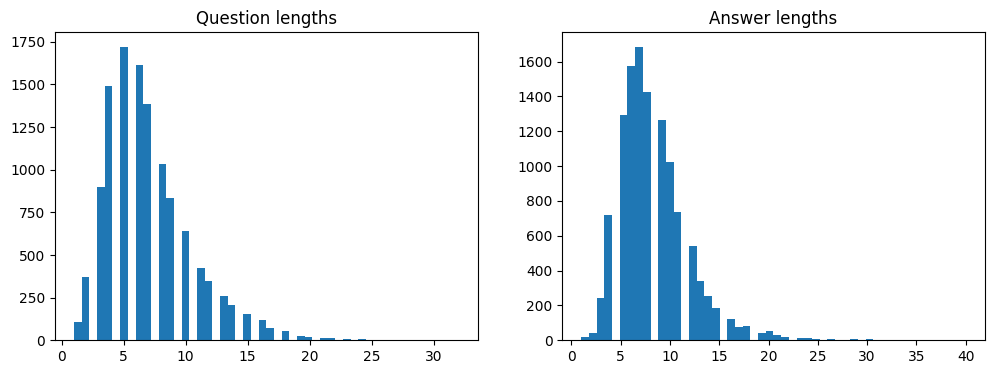

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 모든 문장의 토큰 개수
q_lens = [len(mecab.morphs(preprocess_sentence(q))) for q in questions]
a_lens = [len(mecab.morphs(preprocess_sentence(a))) for a in answers]

print("=== Questions ===")
print(f"  평균: {np.mean(q_lens):.1f}")
print(f"  중앙값: {np.median(q_lens):.0f}")
print(f"  최대: {np.max(q_lens)}")
print(f"  95%: {np.percentile(q_lens, 95):.0f}")
print(f"  99%: {np.percentile(q_lens, 99):.0f}")

print("\n=== Answers ===")
print(f"  평균: {np.mean(a_lens):.1f}")
print(f"  중앙값: {np.median(a_lens):.0f}")
print(f"  최대: {np.max(a_lens)}")
print(f"  95%: {np.percentile(a_lens, 95):.0f}")
print(f"  99%: {np.percentile(a_lens, 99):.0f}")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(q_lens, bins=50); axes[0].set_title('Question lengths')
axes[1].hist(a_lens, bins=50); axes[1].set_title('Answer lengths')
plt.show()

- 문장내 형태소 갯수 데이터 분포 결과 Q, A 모두 99%가 20이내 이므로 max_len=20 으로 정의함.  

### 3-2 토큰화
- que_corpus, ans_corpus 에 각각 토큰화 하여 저장.

In [ ]:
que_corpus, ans_corpus = build_corpus(
    questions, answers,
    tokenizer=mecab.morphs,
    max_len=20   # 위 분석 결과로 정의.
)

print(f"원본 데이터 수: {len(questions)}")
print(f"필터 후 수    : {len(que_corpus)}")
print()
print("=== 샘플 3개 ===")
for i in range(3):
    print(f"[Q] {que_corpus[i]}")
    print(f"[A] {ans_corpus[i]}")
    print()

원본 데이터 수: 11823
필터 후 수    : 11597

=== 샘플 3개 ===
[Q] ['12', '시', '땡', '!']
[A] ['하루', '가', '또', '가', '네요', '.']

[Q] ['1', '지망', '학교', '떨어졌', '어']
[A] ['위로', '해', '드립니다', '.']

[Q] ['3', '박', '4', '일', '놀', '러', '가', '고', '싶', '다']
[A] ['여행', '은', '언제나', '좋', '죠', '.']



- **중복제거방식 변경**
    - 중복제거 방식을 Q+A 묶어서 하니, 필터 후 데이터 수가 각각 중복 제거 했을 때보다 늘어남.

## Step 4. Augmentation
- 주어진 데이터가 1만개 가량으로 적은 편이므로 데이터 증강을 위해 Lexical Substitution을 적용.
- https://github.com/Kyubyong/wordvectors 에서 Korean (w)를 찾아 다운로드하고, ko.bin 파일로 증강.
- Augmentation된 que_corpus 와 원본 ans_corpus 가 병렬을 이루도록, 이후엔 반대로 원본 que_corpus 와 Augmentation된 ans_corpus 가 병렬을 이루도록 하여 전체 데이터가 원래의 3배가량으로 늘어나도록 함.

```
원본 데이터  : (Q, A)     → 11,000쌍
        ↓
증강 1: Aug(Q) + 원본A    → 11,000쌍 추가
증강 2: 원본 Q + Aug(A)   → 11,000쌍 추가
        ↓
총합  : 약 33,000쌍 (3배)
```

- gensim 3.x Word2Vec 버전 찾아감.

In [ ]:
import pickle

with open(KOBIN_PATH, 'rb') as f:
    obj = pickle.load(f, encoding='latin1')

print("타입:", type(obj))
print("속성:", [a for a in dir(obj) if not a.startswith('_')][:30])

타입: <class 'gensim.models.word2vec.Word2Vec'>
속성: ['add_lifecycle_event', 'add_null_word', 'alpha', 'batch_words', 'build_vocab', 'build_vocab_from_freq', 'cbow_mean', 'corpus_count', 'create_binary_tree', 'estimate_memory', 'get_latest_training_loss', 'hashfxn', 'hs', 'index2word', 'init_sims', 'init_weights', 'iter', 'layer1_size', 'load', 'make_cum_table', 'max_vocab_size', 'min_alpha', 'min_alpha_yet_reached', 'min_count', 'negative', 'null_word', 'predict_output_word', 'prepare_vocab', 'prepare_weights', 'random']


- 데이터 확인

In [ ]:
# 어휘 리스트
print("어휘 수:", len(obj.index2word))
print("샘플 단어:", obj.index2word[:10])

# 벡터 확인 (둘 중 하나에 있을 것)
for attr in ['syn0', 'wv', 'vectors']:
    if hasattr(obj, attr):
        print(f"  obj.{attr} 있음 → 타입: {type(getattr(obj, attr))}")

어휘 수: 30185
샘플 단어: ['하', '이', 'ㄴ', '의', '는', '다', '에', '을', '었', '은']
  obj.syn0 있음 → 타입: <class 'numpy.ndarray'>


-  최신 gensim KeyedVectors로 변환

In [ ]:
import numpy as np
from gensim.models import KeyedVectors

vocab_list = obj.index2word
vectors = obj.syn0

print(f"단어 수      : {len(vocab_list):,}")
print(f"벡터 shape   : {vectors.shape}")
print(f"임베딩 차원  : {vectors.shape[1]}")

# 최신 gensim KeyedVectors로 변환
kv = KeyedVectors(vector_size=vectors.shape[1])  # 한국어 사전 학습된 단어 임베딩
kv.add_vectors(vocab_list, vectors)

# 메모리 절약
del obj

print("\n KeyedVectors 변환 완료!")

단어 수      : 30,185
벡터 shape   : (30185, 200)
임베딩 차원  : 200

 KeyedVectors 변환 완료!


- 유사 단어 검색 되는지 확인(kv)

In [ ]:
# 유사 단어 검색 테스트
test_words = ['사랑', '여행', '피곤']

for w in test_words:
    if w in kv:
        sims = kv.most_similar(w, topn=5)
        print(f"\n'{w}'와 유사한 단어:")
        for word, score in sims:
            print(f"  {word}: {score:.3f}")
    else:
        print(f"\n'{w}'는 어휘에 없음")


'사랑'와 유사한 단어:
  슬픔: 0.722
  행복: 0.676
  절망: 0.647
  기쁨: 0.646
  이별: 0.633

'여행'와 유사한 단어:
  항해: 0.602
  탐험: 0.585
  여행자: 0.558
  체류: 0.555
  방문: 0.539

'피곤'와 유사한 단어:
  지루: 0.660
  거만: 0.657
  조용: 0.650
  난폭: 0.649
  지저분: 0.632


### 4-1 데이터 증강
- 처음 lexical_sub() 함수로 1단계 테스트 후 응답이 자연스럽지 않아서,
2단계 safe_lexical_sub()로 변경.

In [ ]:
def lexical_sub(tokens, kv, p=0.3, topn=3):
    """
        문장의 일부 토큰을 Word2Vec 유사 단어로 치환 (Lexical Substitution)

    Args:
        tokens : 형태소 리스트  예) ['1', '지망', '학교', '떨어졌', '어']
        kv     : gensim KeyedVectors (Word2Vec 임베딩)
        p      : 각 토큰을 치환 시도할 치환확률 (0.3 = 30%/0.1~0.3이 가장 안정적)
        topn   : 유사 단어 후보 개수 (이 중에서 1개 랜덤 선택)

    Returns:
        치환된 새 토큰 리스트
    """
    result = []   # 치환 결과를

    for token in tokens:

        # 1) 치환 조건 검사
        #   - random.random() < p   : 확률 p로 True (예: 0.3이면 30% 확률)
        #   - token in kv           : Word2Vec 어휘에 이 토큰이 있어야 치환 가능함
        if random.random() < p and token in kv:
            try:
                # 2) Word2Vec에서 유사한 단어 topn개 가져오기
                #    예: most_similar("학교", topn=3)
                #    -> [('학원', 0.82), ('대학교', 0.79), ('중학교', 0.77)]
                similar = kv.most_similar(token, topn=topn)

                # 3) topn개 중 1개를 랜덤하게 선택
                #    random.choice(...)  -> 튜플 ('학원', 0.82) 선택
                #    [0]                 -> 단어만 추출 -> '학원'
                new_token = random.choice(similar)[0]

                result.append(new_token)  # 치환된 단어 추가

            except (KeyError, IndexError):
                result.append(token)  # 만약 유사 단어 검색 실패 시 -> 원본 유지
        else:
            # 4) 치환 조건 미달 시 → 원본 그대로 유지
            result.append(token)
    return result


# 샘플 5개로 테스트
print("=== Lexical Substitution 테스트 ===\n")
for i in range(5):
    print(f"원본 Q : {que_corpus[i]}")
    print(f"증강 Q : {lexical_sub(que_corpus[i], kv)}")
    print(f"원본 A : {ans_corpus[i]}")
    print(f"증강 A : {lexical_sub(ans_corpus[i], kv)}")
    print()

=== Lexical Substitution 테스트 ===

원본 Q : ['12', '시', '땡', '!']
증강 Q : ['12', '시의', '끗', '!']
원본 A : ['하루', '가', '또', '가', '네요', '.']
증강 A : ['하루', '가', '설로', '놀드', '더군요', '.']

원본 Q : ['1', '지망', '학교', '떨어졌', '어']
증강 Q : ['1', '지망', '학교', '떨어졌', '어']
원본 A : ['위로', '해', '드립니다', '.']
증강 A : ['무릎', '해', '드립니다', '.']

원본 Q : ['3', '박', '4', '일', '놀', '러', '가', '고', '싶', '다']
증강 Q : ['3', '최', '4', '일', '놀', '러', '놀드', '고', '싶', '다']
원본 A : ['여행', '은', '언제나', '좋', '죠', '.']
증강 A : ['여행', '은', '언제나', '좋', '죠', '.']

원본 Q : ['ppl', '심하', '네']
증강 Q : ['ppl', '강하', '네']
원본 A : ['눈살', '이', '찌푸려', '지', '죠', '.']
증강 A : ['눈살', '이', '찌푸려', '지', '죠', '.']

원본 Q : ['sd', '카드', '망가졌', '어']
증강 Q : ['sd', '카드', '망가졌', '어']
원본 A : ['다시', '새로', '사', '는', '게', '마음', '편해요', '.']
증강 A : ['다시', '새롭', '카', '는다는', '게', '마음', '편해요', '.']



**NEW 데이터 증강**

- 기존 lexical_sub()는 Word2Vec 유사어를 너무 쉽게 치환해서 조사, 어미, 짧은 토큰, 문장부호까지 바뀔 위험이 있음.

- 답변은 증강하지 않고, 질문만 증강하는 방식으로 변경.
```
1. 원본 Q  + 원본 A
2. 증강 Q 1 + 원본 A
3. 증강 Q 2 + 원본 A

원본:
Q: 오늘 너무 피곤해
A: 푹 쉬세요.

증강 1:
Q: 오늘 너무 지쳤어
A: 푹 쉬세요.

증강 2:
Q: 오늘 완전 피곤하다
A: 푹 쉬세요.


```

In [ ]:
import re
import random

# ============================================================
# Safe Lexical Substitution
# ------------------------------------------------------------
# 그래서 아래 함수는 "질문 Q" 증강에만 사용할 안전한 치환 함수이다.
# 답변 A는 정답 역할을 하므로 증강하지 않는 것이 좋다.
# ============================================================


# ------------------------------------------------------------
# 1. 치환하지 않을 토큰 목록
# ------------------------------------------------------------
# 한국어 문장에서 조사/어미/보조 표현은 문법을 만드는 역할을 하므로
# 이런 토큰이 바뀌면 문장이 쉽게 어색해지므로 치환 대상에서 제외한다.
# ------------------------------------------------------------
NO_SUB_TOKENS = {
    # 조사
    "은", "는", "이", "가", "의", "을", "를", "에", "에서", "에게", "한테",
    "으로", "로", "와", "과", "도", "만", "부터", "까지", "보다", "처럼",
    "이나", "나", "랑", "하고",

    # 자주 나오는 어미/보조 표현
    "다", "어", "아", "요", "네요", "죠", "지", "고", "게", "면", "는데",
    "은데", "ㄴ데", "거", "것", "수", "듯",

    "<start>", "<end>", "<pad>", "<unk>",
}

# 후보 단어 끝에 붙어 있으면 어색해질 가능성이 큰 조사/어미
# 예: "학교의", "사람은", "친구가" 같은 후보를 막기 위함
BAD_CANDIDATE_ENDINGS = (
    "의", "은", "는", "이", "가", "을", "를", "에", "로", "으로",
    "와", "과", "도", "만", "랑", "하고"
)

# ------------------------------------------------------------
# 2. 토큰 형태를 검사하기 위한 정규식
# ------------------------------------------------------------
# PUNCT_PATTERN  : 문장부호만 있는 토큰인지 확인
# NUMBER_PATTERN : 숫자만 있는 토큰인지 확인
# KOREAN_PATTERN : 완성형 한글만 있는 토큰인지 확인
# ------------------------------------------------------------
PUNCT_PATTERN  = re.compile(r"^[.,!?]+$")
NUMBER_PATTERN = re.compile(r"^[0-9]+$")
KOREAN_PATTERN = re.compile(r"^[가-힣]+$")


def can_replace_token(token):
    """
    이 토큰을 Word2Vec 유사어로 바꿔도 되는지 1차 검사한다.

    치환하지 않는 경우:
    - 조사/어미/보조 표현
    - 한 글자 이하 토큰
    - 문장부호
    - 숫자
    - 한글이 아닌 토큰
    """
    # 조사, 어미, 특수 토큰은 치환하지 않음
    if token in NO_SUB_TOKENS:
        return False

    # 한 글자 토큰은 의미가 불안정하고 조사/어미일 가능성이 높음
    if len(token) <= 1:
        return False

    # ".", "!", "??" 같은 문장부호는 치환하지 않음
    if PUNCT_PATTERN.match(token):
        return False

    # "12", "2024" 같은 숫자는 치환하지 않음
    if NUMBER_PATTERN.match(token):
        return False

    # 영어, 자모, 특수문자가 섞인 토큰은 치환하지 않음
    if not KOREAN_PATTERN.match(token):
        return False

    return True


def is_valid_replacement(original, candidate, tokenizer):
    """
    Word2Vec이 추천한 후보 단어가 실제 대체어로 안전한지 2차 검사한다.

    검사 기준:
    - 원래 단어와 같으면 제외
    - 완성형 한글 단어만 허용
    - 후보 단어도 치환 금지 토큰이면 제외
    - MeCab으로 다시 토큰화했을 때 하나의 토큰으로 유지되어야 함

    마지막 조건이 중요한 이유:
    Word2Vec 후보가 겉보기에는 한 단어처럼 보여도
    MeCab이 여러 형태소로 쪼개면 문장 길이와 구조가 예상보다 바뀔 수 있다.
    """
    # 같은 단어로 바꾸는 것은 증강 효과가 없으므로 제외
    if candidate == original:
        return False

    if candidate.endswith(BAD_CANDIDATE_ENDINGS):
        return False

    # 한글 단어만 허용
    if not KOREAN_PATTERN.match(candidate):
        return False

    # 후보 단어 자체가 조사/어미/짧은 토큰이면 제외
    if not can_replace_token(candidate):
        return False

    # 후보 단어를 다시 MeCab으로 토큰화
    candidate_tokens = tokenizer(candidate)

    # 하나의 토큰으로 유지되는 후보만 사용
    if len(candidate_tokens) != 1:
        return False

    # 토큰화 결과가 후보 단어와 같아야 함
    if candidate_tokens[0] != candidate:
        return False

    return True


def safe_lexical_sub(tokens, kv, tokenizer, p=0.15, topn=10, min_sim=0.60):
    """
    질문 문장용 안전 Lexical Substitution 함수.

    Args:
        tokens:
            형태소 리스트
            예) ['오늘', '너무', '피곤', '해']

        kv:
            gensim KeyedVectors
            Word2Vec 유사어 검색에 사용

        tokenizer:
            mecab.morphs 같은 토크나이저
            후보 단어가 다시 쪼개지는지 확인할 때 사용

        p:
            각 토큰마다 치환을 시도할 확률
            너무 높으면 문장이 많이 망가지므로 0.15~0.25 정도 권장

        topn:
            Word2Vec에서 가져올 유사어 후보 개수
            후보가 많을수록 선택지는 많아지지만 이상한 단어도 섞일 수 있음

        min_sim:
            유사어로 인정할 최소 유사도
            높이면 안전하지만 증강이 적어지고,
            낮추면 증강은 많아지지만 문장이 어색해질 수 있음

    Returns:
        치환된 새 토큰 리스트
    """
    result = []

    for token in tokens:

        # ----------------------------------------------------
        # 1) 확률 p에 걸리지 않으면 원본 토큰 유지
        # ----------------------------------------------------
        if random.random() >= p:
            result.append(token)
            continue

        # ----------------------------------------------------
        # 2) 조사/어미/숫자/문장부호 등은 치환하지 않음
        # ----------------------------------------------------
        if not can_replace_token(token):
            result.append(token)
            continue

        # ----------------------------------------------------
        # 3) Word2Vec 어휘에 없는 토큰은 유사어를 찾을 수 없으므로 유지
        # ----------------------------------------------------
        if token not in kv:
            result.append(token)
            continue

        # ----------------------------------------------------
        # 4) Word2Vec에서 유사어 후보 topn개 검색
        # ----------------------------------------------------
        try:
            similar = kv.most_similar(token, topn=topn)
        except (KeyError, IndexError):
            result.append(token)
            continue

        # ----------------------------------------------------
        # 5) 유사도와 형태 조건을 모두 통과한 후보만 남김
        # ----------------------------------------------------
        candidates = [
            word
            for word, score in similar
            if score >= min_sim and is_valid_replacement(token, word, tokenizer)
        ]

        # ----------------------------------------------------
        # 6) 안전 후보가 있으면 랜덤 선택, 없으면 원본 유지
        # ----------------------------------------------------
        if candidates:
            result.append(random.choice(candidates))
        else:
            result.append(token)

    return result


# ============================================================
# 샘플 테스트
# ------------------------------------------------------------
# 전체 증강을 실행하기 전에 반드시 몇 개 샘플을 눈으로 확인.
# 여기서는 질문 Q만 증강하고, 답변 A는 원본 그대로 출력.
# ============================================================

print("=== Safe Lexical Substitution 테스트 ===\n")

# 테스트 재현성을 위해 seed 고정
random.seed(42)

for i in range(5):
    aug = safe_lexical_sub(
        que_corpus[i],
        kv,
        tokenizer=mecab.morphs,
        p=0.25,
        topn=10,
        min_sim=0.60
    )

    print(f"원본 Q : {que_corpus[i]}")
    print(f"증강 Q : {aug}")
    print(f"원본 A : {ans_corpus[i]}")
    print()


=== Safe Lexical Substitution 테스트 ===

원본 Q : ['12', '시', '땡', '!']
증강 Q : ['12', '시', '땡', '!']
원본 A : ['하루', '가', '또', '가', '네요', '.']

원본 Q : ['1', '지망', '학교', '떨어졌', '어']
증강 Q : ['1', '지망', '학교', '떨어졌', '어']
원본 A : ['위로', '해', '드립니다', '.']

원본 Q : ['3', '박', '4', '일', '놀', '러', '가', '고', '싶', '다']
증강 Q : ['3', '박', '4', '일', '놀', '러', '가', '고', '싶', '다']
원본 A : ['여행', '은', '언제나', '좋', '죠', '.']

원본 Q : ['3', '박', '4', '일', '정도', '놀', '러', '가', '고', '싶', '다']
증강 Q : ['3', '박', '4', '일', '만큼', '놀', '러', '가', '고', '싶', '다']
원본 A : ['여행', '은', '언제나', '좋', '죠', '.']

원본 Q : ['ppl', '심하', '네']
증강 Q : ['ppl', '심각', '네']
원본 A : ['눈살', '이', '찌푸려', '지', '죠', '.']



### 4-2 데이터 증강

#### 4-2-1  1단계 전체 데이터 증강 실행

In [ ]:
# --------------------------
# que_corpus  : 원본 질문들
# ans_corpus  : 원본 답변들
# que_aug     : 치환된 질문들
# ans_aug     : 치환된 답변들
# --------------------------
import random
random.seed(42)   # 재현성

print("증강 시작... (1~2분 소요)")

# 1) 증강(치환)된 질문들의 리스트
que_aug = [lexical_sub(q, kv, p=0.3, topn=3) for q in que_corpus]

# 2) 증강(치환)된 답변들의 리스트
ans_aug = [lexical_sub(a, kv, p=0.3, topn=3) for a in ans_corpus]

# 3) 합치기 (순서가 맞아야 함.)
que_final = que_corpus + que_aug      + que_corpus  # 원본Q + 증강Q + 원본Q
ans_final = ans_corpus + ans_corpus   + ans_aug     # 원본A + 원본A + 증강A

print(f"\n원본       : {len(que_corpus):,}쌍")
print(f"증강 후 총합: {len(que_final):,}쌍  (≈ 3배)")
assert len(que_final) == len(ans_final), "Q와 A 개수 다름!"

증강 시작... (1~2분 소요)


NameError: name 'lexical_sub' is not defined

#### 4-2-1 2단계 전체 데이터 증강 실행

In [ ]:
# ============================================================
# 전체 데이터 증강 실행
# ------------------------------------------------------------
# 목표:
#   원본 Q + 원본 A
#   증강 Q1 + 원본 A
#   증강 Q2 + 원본 A
#
# 답변 A는 정답 역할을 하므로 증강하지 않는다.
# 질문 Q만 2번 다르게 증강해서 전체 데이터를 3배로 만든다.
# ============================================================

import random

print("Q-only 증강 시작...")

# 재현성을 위해 seed 고정
random.seed(42)

# 1) 질문 증강 버전 1
#    p를 낮게 잡아서 비교적 보수적으로 치환
que_aug_1 = [
    safe_lexical_sub(
        q,
        kv,
        tokenizer=mecab.morphs,
        p=0.15,
        topn=10,
        min_sim=0.60
    )
    for q in que_corpus
]

# 2) 질문 증강 버전 2
#    p를 조금 높여서 첫 번째 증강보다 더 다양한 질문 생성
que_aug_2 = [
    safe_lexical_sub(
        q,
        kv,
        tokenizer=mecab.morphs,
        p=0.25,
        topn=10,
        min_sim=0.60
    )
    for q in que_corpus
]

# 3) 최종 학습 데이터 구성
#    A는 원본 답변을 그대로 3번 반복
que_final = que_corpus + que_aug_1 + que_aug_2
ans_final = ans_corpus + ans_corpus + ans_corpus

print(f"\n원본 데이터 수      : {len(que_corpus):,}쌍")
print(f"증강 Q1 데이터 수   : {len(que_aug_1):,}쌍")
print(f"증강 Q2 데이터 수   : {len(que_aug_2):,}쌍")
print(f"증강 후 총 데이터 수: {len(que_final):,}쌍")

assert len(que_final) == len(ans_final), "Q와 A 개수가 다릅니다!"

print("\n=== 증강 샘플 확인 ===")
for i in range(15):
    print(f"\n[{i}]")
    print(f"원본 Q : {que_corpus[i]}")
    print(f"증강 Q1: {que_aug_1[i]}")
    print(f"증강 Q2: {que_aug_2[i]}")
    print(f"원본 A : {ans_corpus[i]}")


Q-only 증강 시작...

원본 데이터 수      : 11,597쌍
증강 Q1 데이터 수   : 11,597쌍
증강 Q2 데이터 수   : 11,597쌍
증강 후 총 데이터 수: 34,791쌍

=== 증강 샘플 확인 ===

[0]
원본 Q : ['12', '시', '땡', '!']
증강 Q1: ['12', '시', '땡', '!']
증강 Q2: ['12', '시', '땡', '!']
원본 A : ['하루', '가', '또', '가', '네요', '.']

[1]
원본 Q : ['1', '지망', '학교', '떨어졌', '어']
증강 Q1: ['1', '지망', '학교', '떨어졌', '어']
증강 Q2: ['1', '중퇴', '학교', '떨어졌', '어']
원본 A : ['위로', '해', '드립니다', '.']

[2]
원본 Q : ['3', '박', '4', '일', '놀', '러', '가', '고', '싶', '다']
증강 Q1: ['3', '박', '4', '일', '놀', '러', '가', '고', '싶', '다']
증강 Q2: ['3', '박', '4', '일', '놀', '러', '가', '고', '싶', '다']
원본 A : ['여행', '은', '언제나', '좋', '죠', '.']

[3]
원본 Q : ['3', '박', '4', '일', '정도', '놀', '러', '가', '고', '싶', '다']
증강 Q1: ['3', '박', '4', '일', '정도', '놀', '러', '가', '고', '싶', '다']
증강 Q2: ['3', '박', '4', '일', '정도', '놀', '러', '가', '고', '싶', '다']
원본 A : ['여행', '은', '언제나', '좋', '죠', '.']

[4]
원본 Q : ['ppl', '심하', '네']
증강 Q1: ['ppl', '심하', '네']
증강 Q2: ['ppl', '시끄럽', '네']
원본 A : ['눈살', '이', '찌푸려', '지', '죠', '.']

[5]
원본 

#### 4-2-1 3단계 데이터 증강 실행

In [ ]:
# ============================================================
# Train만 Q-only 증강 실행
# ------------------------------------------------------------
# 목표:
#   1. 원본 que_corpus / ans_corpus를 먼저 train / val로 분리
#   2. train 질문만 2번 증강
#   3. val은 원본 그대로 유지
#
# 이렇게 해야 train과 val 사이에 원본 계열 누수가 생기지 않는다.
# ============================================================

from sklearn.model_selection import train_test_split
import random

print("Train/Val 분리 후 Train만 Q-only 증강 시작...")

random.seed(42)

# 1) 원본 데이터 기준으로 먼저 train / val 분리
que_train, que_val, ans_train, ans_val = train_test_split(
    que_corpus,
    ans_corpus,
    test_size=0.1,
    random_state=42
)

# 2) train 질문만 증강 버전 1 생성
que_aug_1 = [
    safe_lexical_sub(
        q,
        kv,
        tokenizer=mecab.morphs,
        p=0.15,
        topn=10,
        min_sim=0.60
    )
    for q in que_train
]

# 3) train 질문만 증강 버전 2 생성
que_aug_2 = [
    safe_lexical_sub(
        q,
        kv,
        tokenizer=mecab.morphs,
        p=0.25,
        topn=10,
        min_sim=0.60
    )
    for q in que_train
]

# 4) 최종 train 데이터 구성
#    답변은 증강하지 않고 원본 답변을 그대로 반복
que_final = que_train + que_aug_1 + que_aug_2
ans_final = ans_train + ans_train + ans_train

# 5) val 데이터는 원본 그대로 유지
que_val_final = que_val
ans_val_final = ans_val

print(f"\n원본 전체 데이터 수     : {len(que_corpus):,}쌍")
print(f"Train 원본 데이터 수    : {len(que_train):,}쌍")
print(f"Val 원본 데이터 수      : {len(que_val):,}쌍")
print(f"Train 증강 Q1 데이터 수 : {len(que_aug_1):,}쌍")
print(f"Train 증강 Q2 데이터 수 : {len(que_aug_2):,}쌍")
print(f"최종 Train 데이터 수    : {len(que_final):,}쌍")
print(f"최종 Val 데이터 수      : {len(que_val_final):,}쌍")

assert len(que_final) == len(ans_final), "Train Q와 A 개수가 다릅니다!"
assert len(que_val_final) == len(ans_val_final), "Val Q와 A 개수가 다릅니다!"

print("\n=== Train 증강 샘플 확인 ===")
for i in range(5):
    print(f"\n[{i}]")
    print(f"원본 Q : {que_train[i]}")
    print(f"증강 Q1: {que_aug_1[i]}")
    print(f"증강 Q2: {que_aug_2[i]}")
    print(f"원본 A : {ans_train[i]}")


Train/Val 분리 후 Train만 Q-only 증강 시작...

원본 전체 데이터 수     : 11,597쌍
Train 원본 데이터 수    : 10,437쌍
Val 원본 데이터 수      : 1,160쌍
Train 증강 Q1 데이터 수 : 10,437쌍
Train 증강 Q2 데이터 수 : 10,437쌍
최종 Train 데이터 수    : 31,311쌍
최종 Val 데이터 수      : 1,160쌍

=== Train 증강 샘플 확인 ===

[0]
원본 Q : ['화이트데이', '에', '뭐', '선물', '하', '지']
증강 Q1: ['화이트데이', '에', '뭐', '선물', '하', '지']
증강 Q2: ['화이트데이', '에', '뭐', '선물', '하', '지']
원본 A : ['사탕', '만들', '어요', '.']

[1]
원본 Q : ['어린이집', '방학', '이래']
증강 Q1: ['어린이집', '학기', '이후']
증강 Q2: ['어린이집', '방학', '이래']
원본 A : ['육아', '파이팅', '!', '!']

[2]
원본 Q : ['퇴근', '하', '고', '뭐', '하', '지']
증강 Q1: ['퇴근', '하', '고', '뭐', '하', '지']
증강 Q2: ['퇴근', '하', '고', '뭐', '하', '지']
원본 A : ['몸', '과', '마음', '이', '좀', '쉬', '어야', '할', '것', '같', '아요', '.']

[3]
원본 Q : ['헤어진지', '3', '달째', '인데', '후폭풍', '왔', '나', '봐', 'ㅠ']
증강 Q1: ['헤어진지', '3', '달째', '인데', '후폭풍', '왔', '나', '봐', 'ㅠ']
증강 Q2: ['헤어진지', '3', '달째', '인데', '후폭풍', '왔', '나', '봐', 'ㅠ']
원본 A : ['헤어짐', '에', '도', '처', '방약', '이', '있', '으면', '좋', '겠', '어요', '.']

[4]
원본 Q

## Step 5. 데이터 벡터화
- 타겟 데이터인 ans_corpus 에 <start> 토큰과 <end> 토큰이 추가되지 않은 상태이니 이를 먼저 해결한 후 벡터화를 진행.

1) \<start>, \<end> 토큰을 답변에 추가
2) Q와 A 합쳐서 공유 vocab 구축 (단어 → 정수 매핑)
3) 벡터화 — 토큰 리스트 → 정수 시퀀스

### 5-1  답변에 특수 토큰 추가

- 1,2 단계

In [ ]:
# sample_data = ["12", "시", "땡", "!"]
# ["<start>"] + sample_data + ["<end>"]

ans_final = [["<start>"] + a + ["<end>"] for a in ans_final]

# 원본 / 증강 Q1 / 증강 Q2 위치 확인용 인덱스
n_original = len(que_corpus)

sample_indices = [
    0,               # 원본 데이터 첫 번째
    n_original,      # 증강 Q1 첫 번째
    n_original * 2   # 증강 Q2 첫 번째
]

# 확인
print("=== 특수 토큰 추가 확인 ===")
for i in sample_indices:
    print(f"index: {i}")
    print(f"Q: {que_final[i]}")
    print(f"A: {ans_final[i]}")
    print()

=== 특수 토큰 추가 확인 ===
index: 0
Q: ['12', '시', '땡', '!']
A: ['<start>', '하루', '가', '또', '가', '네요', '.', '<end>']

index: 11597
Q: ['12', '시', '땡', '!']
A: ['<start>', '하루', '가', '또', '가', '네요', '.', '<end>']

index: 23194
Q: ['12', '시', '땡', '!']
A: ['<start>', '하루', '가', '또', '가', '네요', '.', '<end>']



- 3단계

In [ ]:
# ============================================================
# 답변에 <start>, <end> 토큰 추가
# ------------------------------------------------------------
# Train 답변과 Val 답변을 각각 처리한다.
#
# 주의:
# 이 셀을 여러 번 실행하면 <start>, <end>가 중복으로 붙을 수 있다.
# 다시 실행해야 한다면 바로 앞의
# "Train만 Q-only 증강 실행" 셀을 먼저 다시 실행한 뒤 실행한다.
# ============================================================

ans_final = [["<start>"] + a + ["<end>"] for a in ans_final]
ans_val_final = [["<start>"] + a + ["<end>"] for a in ans_val_final]

# 원본 train / 증강 Q1 / 증강 Q2 위치 확인용 인덱스
n_train = len(que_train)

sample_indices = [
    0,             # train 원본 첫 번째
    n_train,       # train 증강 Q1 첫 번째
    n_train * 2    # train 증강 Q2 첫 번째
]

print("=== Train 특수 토큰 추가 확인 ===")
for i in sample_indices:
    print(f"index: {i}")
    print(f"Q: {que_final[i]}")
    print(f"A: {ans_final[i]}")
    print()

print("=== Val 특수 토큰 추가 확인 ===")
for i in range(3):
    print(f"index: {i}")
    print(f"Q: {que_val_final[i]}")
    print(f"A: {ans_val_final[i]}")
    print()

# 중복 실행 여부 방어용 확인
print("=== 특수 토큰 개수 확인 ===")
print("Train start 개수:", ans_final[0].count("<start>"))
print("Train end 개수  :", ans_final[0].count("<end>"))
print("Val start 개수  :", ans_val_final[0].count("<start>"))
print("Val end 개수    :", ans_val_final[0].count("<end>"))


=== Train 특수 토큰 추가 확인 ===
index: 0
Q: ['화이트데이', '에', '뭐', '선물', '하', '지']
A: ['<start>', '사탕', '만들', '어요', '.', '<end>']

index: 10437
Q: ['화이트데이', '에', '뭐', '선물', '하', '지']
A: ['<start>', '사탕', '만들', '어요', '.', '<end>']

index: 20874
Q: ['화이트데이', '에', '뭐', '선물', '하', '지']
A: ['<start>', '사탕', '만들', '어요', '.', '<end>']

=== Val 특수 토큰 추가 확인 ===
index: 0
Q: ['냄새', '날', '것', '같', '아', '걱정', '이', '야']
A: ['<start>', '괜찮', '아요', '.', '모른', '척하', '세요', '.', '<end>']

index: 1
Q: ['오랜만', '에', '결혼', '한', '친구', '만나', '고', '왔', '는데', '.']
A: ['<start>', '소식', '을', '들', '었', '나', '봐요', '.', '<end>']

index: 2
Q: ['이제', '택시', '안타']
A: ['<start>', '좋', '은', '다짐', '이', '에요', '.', '<end>']

=== 특수 토큰 개수 확인 ===
Train start 개수: 1
Train end 개수  : 1
Val start 개수  : 1
Val end 개수    : 1


In [ ]:
target = ['오늘', '너무', '피곤', '해']

print("=== 특수토큰 추가 후 target 확인 ===")
for i, (q, a) in enumerate(zip(que_final, ans_final)):
    if q == target:
        print("index:", i)
        print("Q:", q)
        print("A:", a)
        break

=== 특수토큰 추가 후 target 확인 ===
index: 2979
Q: ['오늘', '너무', '피곤', '해']
A: ['<start>', '푹', '쉬', '세요', '.', '<end>']


In [ ]:
# 증강한 내용이 너무 동일해서 확인.
def changed_ratio(originals, augmented):
    changed = sum(1 for q, aq in zip(originals, augmented) if q != aq)
    return changed, changed / len(originals)

c1, r1 = changed_ratio(que_train, que_aug_1)
c2, r2 = changed_ratio(que_train, que_aug_2)

print(f"Q1 변경 문장 수: {c1:,} / {len(que_train):,} ({r1:.2%})")
print(f"Q2 변경 문장 수: {c2:,} / {len(que_train):,} ({r2:.2%})")

same_all = sum(
    1 for q, q1, q2 in zip(que_train, que_aug_1, que_aug_2)
    if q == q1 == q2
)

print(f"원본/Q1/Q2 모두 같은 문장 수: {same_all:,} / {len(que_train):,} ({same_all / len(que_train):.2%})")


Q1 변경 문장 수: 2,016 / 10,437 (19.32%)
Q2 변경 문장 수: 3,067 / 10,437 (29.39%)
원본/Q1/Q2 모두 같은 문장 수: 6,227 / 10,437 (59.66%)


In [ ]:
print("=== 실제로 바뀐 증강 샘플 ===")

shown = 0
for q, q1, q2, a in zip(que_train, que_aug_1, que_aug_2, ans_train):
    if q != q1 or q != q2:
        print(f"\n원본 Q : {q}")
        print(f"증강 Q1: {q1}")
        print(f"증강 Q2: {q2}")
        print(f"원본 A : {a}")
        shown += 1

    if shown >= 20:
        break


=== 실제로 바뀐 증강 샘플 ===

원본 Q : ['어린이집', '방학', '이래']
증강 Q1: ['어린이집', '학기', '이후']
증강 Q2: ['어린이집', '방학', '이래']
원본 A : ['육아', '파이팅', '!', '!']

원본 Q : ['고백', '합니다']
증강 Q1: ['고백', '합니다']
증강 Q2: ['회개', '합니다']
원본 A : ['성공', '하', '길', '바랄게요', '.']

원본 Q : ['마음', '이', '너덜너덜', '해졌', '어', '.']
증강 Q1: ['마음', '이', '너덜너덜', '해졌', '어', '.']
증강 Q2: ['괴로움', '이', '너덜너덜', '해졌', '어', '.']
원본 A : ['아픈', '만큼', '행복', '해', '지', '시', '길', '바랄게요', '.']

원본 Q : ['중', '2', '아들', '때', '매', '고민', '이', '야']
증강 Q1: ['중', '2', '아들', '때', '매', '걱정', '이', '야']
증강 Q2: ['중', '2', '손자', '때', '매', '고민', '이', '야']
원본 A : ['사춘기', '인가', '봅니다', '.']

원본 Q : ['그녀', '는', '지금', '무슨', '생각', '을', '할까', '?']
증강 Q1: ['그녀', '는', '지금', '어찌', '생각', '을', '할까', '?']
증강 Q2: ['그녀', '는', '지금', '무슨', '생각', '을', '할까', '?']
원본 A : ['직접', '물', '어', '보', '는', '게', '좋', '겠', '어요', '.']

원본 Q : ['속이', '는', '거', '더', '이상', '못', '하', '겠', '어']
증강 Q1: ['속이', '는', '거', '더', '이상', '못', '하', '겠', '어']
증강 Q2: ['속이', '는', '거', '더', '이하', '못', '하', '겠', '어']
원본

### 5-2 공유 Vocab 구축
- Q + A 모든 토큰 한곳에 모음.

In [ ]:
from collections import Counter

# Q + A 모든 토큰 한곳에 모으기  all_tokens
all_tokens = []
for sent in que_final + ans_final:
    all_tokens.extend(sent)

print(f"전체 토큰 수: {len(all_tokens):,}")

# 빈도 카운트
counter = Counter(all_tokens)
print(f"고유 단어 수: {len(counter):,}")
print(f"\n상위 10개 단어:")
for word, count in counter.most_common(10):
    print(f"  {word}: {count}")


전체 토큰 수: 537,369
고유 단어 수: 7,551

상위 10개 단어:
  .: 36789
  <start>: 31311
  <end>: 31311
  이: 13416
  하: 12288
  는: 11703
  을: 7686
  세요: 7350
  가: 7317
  어: 6528


### 5-3 단어 ↔ 인덱스 매핑

In [ ]:
# 특수 토큰 (인덱스 0~3 고정)
SPECIAL_TOKENS = ['<pad>', '<unk>', '<start>', '<end>']

# vocab(전체 단어 리스트) 구축: 빈도순으로 정렬
vocab = SPECIAL_TOKENS + [w for w, _ in counter.most_common() if w not in SPECIAL_TOKENS]

# 매핑 dict
word2idx = {w: i for i, w in enumerate(vocab)}
idx2word = {i: w for i, w in enumerate(vocab)}

VOCAB_SIZE = len(vocab)
PAD_ID   = word2idx['<pad>']
UNK_ID   = word2idx['<unk>']
START_ID = word2idx['<start>']
END_ID   = word2idx['<end>']

print(f"Vocab 크기: {VOCAB_SIZE:,}")
print(f"PAD={PAD_ID}, UNK={UNK_ID}, START={START_ID}, END={END_ID}")

Vocab 크기: 7,553
PAD=0, UNK=1, START=2, END=3


### 5-4 벡터화 함수 정의 및 실행

- 변수 정리
    - vocab     : 전체 단어 리스트 (인덱스 순서)
    - word2idx  : 단어 -> 정수
    - idx2word  : 정수 -> 단어 (나중에 출력할 때 사용)
    - enc_train : 인코더 입력 (정수화된 Q)
    - dec_train : 디코더 입력 (정수화된 A, \<start>/\<end> 포함)

- **1,2 단계**

In [ ]:
def encode(tokens, word2idx, unk_id):
    """토큰 리스트 → 정수 인덱스 리스트"""
    return [word2idx.get(t, unk_id) for t in tokens]

# 전체 데이터 벡터화
enc_train = [encode(q, word2idx, UNK_ID) for q in que_final]
dec_train = [encode(a, word2idx, UNK_ID) for a in ans_final]

print(f"enc_train 크기: {len(enc_train):,}")
print(f"dec_train 크기: {len(dec_train):,}")
print()
print("=== 샘플 ===")
print(f"[Q tokens] {que_final[0]}")
print(f"[Q ids   ] {enc_train[0]}")
print(f"[A tokens] {ans_final[0]}")
print(f"[A ids   ] {dec_train[0]}")

enc_train 크기: 34,791
dec_train 크기: 34,791

=== 샘플 ===
[Q tokens] ['12', '시', '땡', '!']
[Q ids   ] [2388, 166, 3433, 87]
[A tokens] ['<start>', '하루', '가', '또', '가', '네요', '.', '<end>']
[A ids   ] [2, 247, 10, 143, 10, 35, 4, 3]


- **3단계**

In [ ]:
def encode(tokens, word2idx, unk_id):
    """토큰 리스트 → 정수 인덱스 리스트"""
    return [word2idx.get(t, unk_id) for t in tokens]


# ============================================================
# Train / Val 데이터 벡터화
# ------------------------------------------------------------
# vocab은 train 데이터 기준으로 만들어졌으므로,
# val에만 등장하는 단어는 <unk>로 처리된다.
# 이것이 더 정직한 검증 방식이다.
# ============================================================

enc_train = [encode(q, word2idx, UNK_ID) for q in que_final]
dec_train = [encode(a, word2idx, UNK_ID) for a in ans_final]

enc_val = [encode(q, word2idx, UNK_ID) for q in que_val_final]
dec_val = [encode(a, word2idx, UNK_ID) for a in ans_val_final]

print(f"enc_train 크기: {len(enc_train):,}")
print(f"dec_train 크기: {len(dec_train):,}")
print(f"enc_val 크기  : {len(enc_val):,}")
print(f"dec_val 크기  : {len(dec_val):,}")

assert len(enc_train) == len(dec_train), "Train Q/A 개수가 다릅니다!"
assert len(enc_val) == len(dec_val), "Val Q/A 개수가 다릅니다!"

print("\n=== Train 샘플 ===")
print(f"[Q tokens] {que_final[0]}")
print(f"[Q ids   ] {enc_train[0]}")
print(f"[A tokens] {ans_final[0]}")
print(f"[A ids   ] {dec_train[0]}")

print("\n=== Val 샘플 ===")
print(f"[Q tokens] {que_val_final[0]}")
print(f"[Q ids   ] {enc_val[0]}")
print(f"[A tokens] {ans_val_final[0]}")
print(f"[A ids   ] {dec_val[0]}")

# Val에서 <unk>가 얼마나 생기는지 확인
val_token_count = sum(len(q) for q in enc_val) + sum(len(a) for a in dec_val)
val_unk_count = (
    sum(seq.count(UNK_ID) for seq in enc_val)
    + sum(seq.count(UNK_ID) for seq in dec_val)
)

print("\n=== Val <unk> 비율 ===")
print(f"Val 전체 토큰 수: {val_token_count:,}")
print(f"Val <unk> 수    : {val_unk_count:,}")
print(f"Val <unk> 비율  : {val_unk_count / val_token_count:.2%}")


enc_train 크기: 31,311
dec_train 크기: 31,311
enc_val 크기  : 1,160
dec_val 크기  : 1,160

=== Train 샘플 ===
[Q tokens] ['화이트데이', '에', '뭐', '선물', '하', '지']
[Q ids   ] [1709, 26, 93, 169, 6, 19]
[A tokens] ['<start>', '사탕', '만들', '어요', '.', '<end>']
[A ids   ] [2, 2183, 238, 29, 4, 3]

=== Val 샘플 ===
[Q tokens] ['냄새', '날', '것', '같', '아', '걱정', '이', '야']
[Q ids   ] [1220, 146, 44, 33, 23, 229, 5, 90]
[A tokens] ['<start>', '괜찮', '아요', '.', '모른', '척하', '세요', '.', '<end>']
[A ids   ] [2, 110, 46, 4, 1715, 1900, 9, 4, 3]

=== Val <unk> 비율 ===
Val 전체 토큰 수: 20,169
Val <unk> 수    : 227
Val <unk> 비율  : 1.13%


## Step 6. 훈련하기

```
6-1. Dataset & DataLoader 만들기 (패딩 포함)
6-2. Transformer 모델 정의
   ├─ Positional Encoding
   ├─ Multi-Head Attention
   ├─ Encoder/Decoder Block
   └─ 전체 모델
6-3. 학습 유틸 (마스크, 손실함수, Optimizer + Warmup)
6-4. 학습 루프
6-5. 추론 함수 (챗봇 응답 생성)
6-6. 예문 테스트
```

### 6-1. Dataset & DataLoader 만들기 (패딩 포함)

#### 6-1-1 데이터 분할
    - 전체 데이터를 train(학습용) / val(검증용) 10% 으로 나눔

In [ ]:
# ==========================================
# 6-1-1: 학습/검증 데이터 분할
# ==========================================
# - 전체 데이터를 train(학습용) / val(검증용)으로 나눔
# - test_size=0.1   → 10%를 val로 설정
# - random_state=42 → SEED 고정
# ==========================================

import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from sklearn.model_selection import train_test_split

# 1,2 단계
# # 인코더 학습, 평가, 디코더 학습, 평가
# enc_tr, enc_val, dec_tr, dec_val = train_test_split(
#     enc_train, dec_train,   # 인코더 입력(Q), 디코더 입력(A)
#     test_size=0.1,          # 10%를 검증용으로
#     random_state=42         # 시드 고정
# )

# 3단계
enc_tr = enc_train
dec_tr = dec_train

print(f"Train: {len(enc_tr):,}쌍")
print(f"Val  : {len(enc_val):,}쌍")

assert len(enc_tr) == len(dec_tr), "Train Q/A 개수가 다릅니다!"
assert len(enc_val) == len(dec_val), "Val Q/A 개수가 다릅니다!"

Train: 31,311쌍
Val  : 1,160쌍


#### 6-1-2 PyTorch Dataset 정의
- 모델은 텐서만 처리하므로 정리 list -> 텐서로 변환해서 리턴

In [ ]:
# ==========================================
# 6-1-2: PyTorch Dataset 정의
# ==========================================
# - PyTorch가 데이터를 한 개씩 꺼낼 수 있게 만드는 클래스
#   __init__   : 초기화 (데이터 받아서 저장)
#   __len__    : 전체 데이터 수
#   __getitem__: idx번째 데이터 1개 반환
# ==========================================

class ChatDataset(Dataset):
    def __init__(self, enc, dec):
        self.enc = enc   # enc: 질문(Q) 리스트
        self.dec = dec   # dec: 답변(A) 리스트

    def __len__(self):
        # 전체 데이터 개수
        return len(self.enc)

    def __getitem__(self, idx):
        # idx번째 (Q, A) 쌍을 tensor로 변환해서 반환
        # dtype=torch.long → 정수 (인덱스는 정수여야 함)
        src = torch.tensor(self.enc[idx], dtype=torch.long)
        tgt = torch.tensor(self.dec[idx], dtype=torch.long)
        return src, tgt

#### 6-1-3 배치 묶기 / 패딩처리
- 각 배치별 최대 길이 기준으로 패딩처리 함. 배치별 가변으로 메모리 효율 올림.

In [ ]:
# ==========================================
# 6-1-3: 배치 묶기 + 패딩 처리
# ==========================================
# - DataLoader가 여러 샘플을 묶어서 배치를 만들 때 호출됨
# - 배치 안의 문장들 길이가 다 다름.
# - pad_sequence로 가장 긴 문장에 맞춰 <pad> 채워서 리턴함.
# ==========================================

def collate_fn(batch):
    """
    batch = [(src1, tgt1), (src2, tgt2), ...] 형태로 들어옴
    """
    # 1) src끼리, tgt끼리 분리
    srcs, tgts = zip(*batch)  # 예: srcs = (tensor([42,17,4]), tensor([5,8,3,1,4]), ...)


    # 2) 패딩 적용 — 배치 내 최대 길이에 맞춤
    src_padded = pad_sequence(
        srcs,
        batch_first=True,         # shape: (batch, seq_len) ← batch가 앞
        padding_value=PAD_ID      # 빈 자리에 <pad>(=0) 채움
    )
    tgt_padded = pad_sequence(
        tgts,
        batch_first=True,
        padding_value=PAD_ID
    )

    return src_padded, tgt_padded

#### 6-1-4  DataLoader 만들기

In [ ]:
# ==========================================
# 6-1-4: DataLoader 만들기
# ==========================================
# - DataLoader: Dataset에서 배치 단위로 꺼내줌
# - 주요 옵션:
#   batch_size  : 한 배치에 들어갈 샘플 수
#   shuffle     : 매 에폭마다 순서 섞기 (train만 True)
#   collate_fn  : 위에서 만든 패딩 함수
#   num_workers : 병렬 로딩 프로세스 수
# ==========================================

BATCH_SIZE = 64   # 한 배치에 들어갈 샘플 수

# Dataset 인스턴스 생성
train_dataset = ChatDataset(enc_tr,  dec_tr)  # 학습용 데이터셋
val_dataset   = ChatDataset(enc_val, dec_val) # 평가용 데이터셋

# Train Loader (셔플 ON)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,             # 매 에폭마다 순서 섞음 (학습 안정성)
    collate_fn=collate_fn,
    num_workers=2             # 데이터 로딩 병렬화
)

# Val Loader (셔플 OFF)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,            # 검증은 순서 그대로
    collate_fn=collate_fn,
    num_workers=2
)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches  : {len(val_loader)}")

Train batches: 490
Val batches  : 19


#### 6-1-5 DataLoader 동작 확인

In [ ]:
# ==========================================
# 6-1-5: DataLoader 동작 확인
# ==========================================
# - 첫 배치 하나만 꺼내서 모양과 내용 확인
# - 정수 인덱스를 다시 단어로 복원해서 사람이 읽을 수 있게
# ==========================================

for src, tgt in train_loader:
    # 텐서 모양 확인
    print(f"src shape: {src.shape}")
    # (64, N) → 배치 64개, 각 문장 길이 N (패딩 후)

    print(f"tgt shape: {tgt.shape}")

    # 첫 번째 샘플의 정수 인덱스 (앞 15개만)
    print(f"\n--- 정수 인덱스 ---")
    print(f"Q: {src[0][:15].tolist()}")
    print(f"A: {tgt[0][:15].tolist()}")

    # idx2word로 다시 단어로 복원 (사람이 읽기 좋게)
    print(f"\n--- 단어 복원 ---")
    q_words = [idx2word[i.item()] for i in src[0] if i.item() != PAD_ID]
    a_words = [idx2word[i.item()] for i in tgt[0] if i.item() != PAD_ID]
    print(f"Q: {' '.join(q_words)}")
    print(f"A: {' '.join(a_words)}")

    break   # 첫 배치만 보고 중단

src shape: torch.Size([64, 17])
tgt shape: torch.Size([64, 16])

--- 정수 인덱스 ---
Q: [1327, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
A: [2, 3107, 10, 12, 3108, 330, 14, 27, 4, 3, 0, 0, 0, 0, 0]

--- 단어 복원 ---
Q: 최악
A: <start> 똥차 가 고 벤츠 올 거 예요 . <end>


In [ ]:
target = ['오늘', '너무', '피곤', '해']

print("=== 벡터화 후 target 확인 ===")
for i, (q, a) in enumerate(zip(que_final, ans_final)):
    if q == target:
        print("index:", i)
        print("Q:", q)
        print("A:", a)
        print("A ids:", dec_train[i])
        print("decoded:", [idx2word[x] for x in dec_train[i]])
        break



=== 벡터화 후 target 확인 ===
index: 2979
Q: ['오늘', '너무', '피곤', '해']
A: ['<start>', '푹', '쉬', '세요', '.', '<end>']
A ids: [2, 1206, 226, 9, 4, 3]
decoded: ['<start>', '푹', '쉬', '세요', '.', '<end>']


### 6-2 Transformer 모델 정의
```
1. Positional Encoding  (위치 정보 추가)
2. 마스크 함수          (패딩/미래 가리기)
3. Transformer 모델     (메인)
```

#### 6-2-1 Positional Encoding
- 순서정보가 없으므로 각 위치마다 sin(짝수차원)/cos(홀수) 패턴 벡터를 더해줌
- 학습 없이 계산식으로 위치 정보 부여하여 두 벡터의 상대적 거리 계산이 가능해짐.

In [ ]:
# ==========================================
# 6-2-1: Positional Encoding
# ==========================================
# - Transformer는 RNN과 달리 순서 정보가 없음
# - 각 위치마다 고유한 sin(짝수)/cos(홀수) 패턴 벡터를 더해줌
# ==========================================

import numpy as np

def positional_encoding(pos, d_model):
    """
    pos     : 최대 시퀀스 길이 (예: 200)
    d_model : 임베딩 차원 (예: 368)
    return  : (pos, d_model) numpy array
    """
    def cal_angle(position, i):
        # 각 (위치, 차원)에 대한 각도 계산
        return position / np.power(10000, (2 * (i // 2)) / np.float32(d_model))

    def get_posi_angle_vec(position):
        return [cal_angle(position, i) for i in range(d_model)]

    # (pos, d_model) 크기의 각도 테이블
    sinusoid_table = np.array([get_posi_angle_vec(pos_i) for pos_i in range(pos)])

    # 짝수 인덱스 → sin, 홀수 인덱스 → cos
    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2])

    return sinusoid_table

print("Positional encoding 함수 정의 완료")

Positional encoding 함수 정의 완료


#### 6-2-2 Attention Mask 함수



```

[Look-ahead Mask]

   t=0  t=1  t=2  t=3  t=4
t=0  0    1    1    1    1     ← t=0은 자기만 봄
t=1  0    0    1    1    1     ← t=1은 t=0, t=1만 봄
t=2  0    0    0    1    1
t=3  0    0    0    0    1
t=4  0    0    0    0    0     ← t=4는 다 봄

(1=가려짐, 0=볼 수 있음)
```


In [ ]:
# ==========================================
# 6-2-2: Attention Mask 함수
# ==========================================
# 핵심: 마스크가 float이고 4D
#   - 가려야 할 위치 = 1.0
#   - 사용할 위치    = 0.0
# Attention 계산 시 (mask * -1e9) 를 더해 softmax에서 0 만듦
# ==========================================

import torch

def generate_padding_mask(seq):
    """
    seq    : [batch, seq_len]
    return : [batch, 1, 1, seq_len] - <pad>(=0) 위치가 1.0
    """
    # PAD_ID == 0 이므로 seq == 0 로 검사
    return (seq == PAD_ID).unsqueeze(1).unsqueeze(2).float()


def generate_lookahead_mask(size):
    """
    size   : 시퀀스 길이
    return : [size, size] - 상삼각이 1.0 (미래 위치 가림)
    """
    return torch.triu(torch.ones(size, size), diagonal=1)


def generate_masks(src, tgt):
    """
    src, tgt: [batch, seq_len]

    return:
      enc_mask     : [batch, 1, 1, src_len]  - 인코더 self-attn용
      dec_enc_mask : [batch, 1, 1, src_len]  - 디코더의 cross-attn용 (src 패딩 가림)
      dec_mask     : [batch, 1, tgt_len, tgt_len] - 디코더 self-attn용 (lookahead + 패딩)
    """
    # 1) 인코더 self-attention 마스크 (src 패딩 가림)
    enc_mask = generate_padding_mask(src)

    # 2) Cross-attention 마스크 (디코더가 인코더 출력 볼 때 src 패딩 가림)
    dec_enc_mask = generate_padding_mask(src)

    # 3) 디코더 self-attention 마스크 (lookahead + tgt 패딩)
    dec_lookahead_mask = generate_lookahead_mask(tgt.shape[1])      # [tgt_len, tgt_len]
    dec_tgt_padding_mask = generate_padding_mask(tgt)               # [batch, 1, 1, tgt_len]

    # lookahead를 (1, 1, tgt_len, tgt_len)로 확장 → 브로드캐스팅
    dec_lookahead_mask = dec_lookahead_mask.unsqueeze(0).unsqueeze(1)

    # device로 이동
    dec_tgt_padding_mask = dec_tgt_padding_mask.to(device)
    dec_lookahead_mask   = dec_lookahead_mask.to(device)

    # 두 마스크 합치기: 둘 중 하나라도 1이면 가림 (torch.max)
    dec_mask = torch.max(dec_tgt_padding_mask, dec_lookahead_mask)

    return enc_mask, dec_enc_mask, dec_mask

print("마스크 함수 정의 완료")

마스크 함수 정의 완료


#### 6-2-3 Multi-Head Attention

In [ ]:
# ==========================================
# 6-2-3: Multi-Head Attention
# ==========================================
# 내용:
#   - d_model을 num_heads로 쪼개서 여러 관점으로 attention
#   - 각 head가 depth = d_model // num_heads 차원 담당
#
# 흐름:
#   Q,K,V → 선형변환 → split_heads → scaled-dot-product
#         → combine_heads → 최종 선형
# ==========================================

import torch
import torch.nn as nn
import torch.nn.functional as F

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model
        self.depth = d_model // num_heads   # 각 head 담당 차원

        # Q, K, V 선형 변환
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)

        # head 결합 후 최종 선형
        self.linear = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        """
        Attention(Q,K,V) = softmax(Q·Kᵀ / √d_k) · V

        Q,K,V : [batch, num_heads, seq_len, depth]
        mask  : [batch, 1, seq_len, seq_len] (1=가림)
        """
        d_k = Q.size(-1)

        # 1. Q와 K 내적(Q·Kᵀ) → attention 점수(단어 간 관련도 점수)
        QK = torch.matmul(Q, K.transpose(-1, -2))

        # 2. 스케일링 (√d_k로 나눔:점수가 너무 커지는 것 방지)
        scaled_qk = QK / torch.sqrt(torch.tensor(d_k, dtype=torch.float32))

        # 3. 마스크 적용: 1인 위치에 -1e9 더해 softmax 후 0 만듦(안 볼 곳 가림)
        if mask is not None:
            scaled_qk = scaled_qk + (mask * -1e9)

        # 4. softmax → attention 가중치 (관련 높은 정보 많이 가져옴)
        attentions = F.softmax(scaled_qk, dim=-1)

        # 가중합 → 최종 출력
        out = torch.matmul(attentions, V)
        return out, attentions

    def split_heads(self, x):
        """
        [batch, seq_len, d_model] → [batch, num_heads, seq_len, depth]
        """
        bsz, seq_len, _ = x.size()
        x = x.view(bsz, seq_len, self.num_heads, self.depth)
        x = x.permute(0, 2, 1, 3)   # head를 앞으로
        return x

    def combine_heads(self, x):
        """
        [batch, num_heads, seq_len, depth] → [batch, seq_len, d_model]
        """
        bsz, num_heads, seq_len, depth = x.size()
        x = x.permute(0, 2, 1, 3).contiguous()
        x = x.view(bsz, seq_len, self.d_model)
        return x

    def forward(self, Q, K, V, mask=None):
        # 1) 선형 변환
        WQ = self.W_q(Q)
        WK = self.W_k(K)
        WV = self.W_v(V)

        # 2) 멀티헤드 분할
        WQ_splits = self.split_heads(WQ)
        WK_splits = self.split_heads(WK)
        WV_splits = self.split_heads(WV)

        # 3) Scaled dot-product attention 유사도계산/mask
        out, attention_weights = self.scaled_dot_product_attention(
            WQ_splits, WK_splits, WV_splits, mask
        )

        # 4) head 결합 + 최종 선형
        out = self.combine_heads(out)
        out = self.linear(out)
        return out, attention_weights

print("MultiHeadAttention 정의 완료")

MultiHeadAttention 정의 완료


#### 6-2-4 Position-wise Feed Forward Network
- 각 토큰을 독립적으로 한번 더 가공함
- 표현력 강화

In [ ]:
# ==========================================
# 6-2-4: Position-wise Feed Forward Network
# ==========================================
# - 각 위치(토큰)마다 독립적으로 적용되는 2층 MLP
# - d_model → d_ff (확장) → ReLU → d_ff → d_model (복원)
# - 위치별 정보 가공
# ==========================================

class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff):
        super(PoswiseFeedForwardNet, self).__init__()
        self.d_model = d_model
        self.d_ff = d_ff

        self.fc1 = nn.Linear(d_model, d_ff)    # 확장
        self.fc2 = nn.Linear(d_ff, d_model)    # 복원
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.relu(self.fc1(x))   # 확장 + 비선형
        out = self.fc2(out)            # 복원
        return out

print("PoswiseFeedForwardNet 정의 완료")

PoswiseFeedForwardNet 정의 완료


 #### 6-2-5 Encoder Layer (Pre-LN 구조)

In [ ]:
# ==========================================
# Step 6-2-5: Encoder Layer (Pre-LN 구조)
# ==========================================
# 1개의 인코더 층 = [Self-Attention] + [FFN]
# Pre-LN: 정규화(norm)를 먼저 하고 → 연산 → residual 더함
#
# 흐름:
#   x → norm_1 → self-attn → dropout → +residual
#     → norm_2 → FFN       → dropout → +residual
# ==========================================

class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super(EncoderLayer, self).__init__()
        self.enc_self_attn = MultiHeadAttention(d_model, n_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        # LayerNorm: 마지막 차원(d_model) 기준 정규화
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)

        self.do = nn.Dropout(dropout)

    def forward(self, x, mask):
        # --- 1) Multi-Head Self-Attention ---
        residual = x
        out = self.norm_1(x)                              # 정규화 먼저 (Pre-LN)
        out, enc_attn = self.enc_self_attn(out, out, out, mask)  # Q=K=V=out
        out = self.do(out)
        out = out + residual                              # residual(잔차) connection

        # --- 2) Position-wise Feed Forward ---
        residual = out
        out = self.norm_2(out)                            # 정규화 먼저
        out = self.ffn(out)
        out = self.do(out)
        out = out + residual                              # residual connection

        return out, enc_attn

print("EncoderLayer 정의 완료")

EncoderLayer 정의 완료


#### 6-2-6 Decoder Layer(Pre-LN 구조)

In [ ]:
# ==========================================
# Step 6-2-6: Decoder Layer (Pre-LN 구조)
# ==========================================
# 1개의 디코더 층 = [Masked Self-Attn] + [Cross-Attn] + [FFN]
#
# Encoder와 다른 점:
#   - Self-Attention에 lookahead 마스크 (미래 못 봄)
#   - Cross-Attention 추가 (인코더 출력 참고)
#
# 흐름:
#   x → norm_1 → masked self-attn → +residual
#     → norm_2 → cross-attn(enc_out) → +residual
#     → norm_3 → FFN → +residual
# ==========================================

class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()
        self.dec_self_attn = MultiHeadAttention(d_model, num_heads)   # 자기 자신 (masked)
        self.enc_dec_attn  = MultiHeadAttention(d_model, num_heads)   # 인코더-디코더 (cross)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_3 = nn.LayerNorm(d_model, eps=1e-6)

        self.do = nn.Dropout(dropout)

    def forward(self, x, enc_out, dec_enc_mask, padding_mask):
        # --- 1) Masked Multi-Head Self-Attention ---
        #     디코더가 자기 자신을 보되, 미래 토큰은 못 봄 (padding_mask=dec_mask)
        residual = x
        out = self.norm_1(x)
        out, dec_attn = self.dec_self_attn(out, out, out, mask=padding_mask)
        out = self.do(out)
        out = out + residual

        # --- 2) Encoder-Decoder Cross-Attention ---
        #     Q=디코더, K=V=인코더 출력  ← 질문(인코더) 참고하며 답변 생성
        residual = out
        out = self.norm_2(out)
        out, dec_enc_attn = self.enc_dec_attn(out, enc_out, enc_out, mask=dec_enc_mask)
        out = self.do(out)
        out = out + residual

        # --- 3) Position-wise Feed Forward ---
        residual = out
        out = self.norm_3(out)
        out = self.ffn(out)
        out = self.do(out)
        out = out + residual

        return out, dec_attn, dec_enc_attn

print("DecoderLayer 정의 완료")

DecoderLayer 정의 완료


#### 6-2-7 Encoder

In [ ]:
# ==========================================
# Step 6-2-7: Encoder (final_norm 포함)
# ==========================================
# - EncoderLayer를 n_layers개 쌓음
# - Pre-LN 구조라서 stack 끝에 final_norm 필수!
#   (안 하면 출력이 정규화 안 돼서 학습 불안정)
# ==========================================

class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Encoder, self).__init__()
        self.n_layers = n_layers
        self.enc_layers = nn.ModuleList(
            [EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )
        # Pre-LN 표준: 모든 층 통과 후 마지막 정규화
        self.final_norm = nn.LayerNorm(d_model, eps=1e-6)

    def forward(self, x, mask):
        out = x
        enc_attns = []
        for layer in self.enc_layers:
            out, enc_attn = layer(out, mask)
            enc_attns.append(enc_attn)
        out = self.final_norm(out)   # stack 끝나고 정규화
        return out, enc_attns

print("Encoder 정의 완료 (final_norm 포함)")

Encoder 정의 완료 (final_norm 포함)


#### 6-2-8 Decoder

In [ ]:
# ==========================================
# Step 6-2-8: Decoder (final_norm 포함)
# ==========================================
# - DecoderLayer를 n_layers개 쌓음
# - Pre-LN 구조라서 stack 끝에 final_norm 필수
# ==========================================

class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Decoder, self).__init__()
        self.n_layers = n_layers
        self.dec_layers = nn.ModuleList(
            [DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )
        # Pre-LN 표준: 마지막 정규화
        self.final_norm = nn.LayerNorm(d_model, eps=1e-6)

    def forward(self, x, enc_out, dec_enc_mask, padding_mask):
        out = x
        dec_attns = []
        dec_enc_attns = []
        for layer in self.dec_layers:
            out, dec_attn, dec_enc_attn = layer(out, enc_out, dec_enc_mask, padding_mask)
            dec_attns.append(dec_attn)
            dec_enc_attns.append(dec_enc_attn)
        out = self.final_norm(out)   # stack 끝나고 정규화
        return out, dec_attns, dec_enc_attns

print("Decoder 정의 완료 (final_norm 포함)")

Decoder 정의 완료 (final_norm 포함)


 #### 6-2-9 (Transformer 전체 조립)

In [ ]:
# ==========================================
# Step 6-2-9: Transformer 전체 모델 조립
# ==========================================
# 구조:
#   [Q] → Embedding → +PositionalEncoding → Encoder
#                                              ↓ enc_out
#   [A] → Embedding → +PositionalEncoding → Decoder ← cross-attn
#                                              ↓
#                                           Linear(fc) → vocab logits
#
# 핵심 옵션:
#   shared_emb : 인코더/디코더 임베딩 공유 (챗봇=같은 언어 → True)
#   shared_fc  : 출력 fc와 디코더 임베딩 weight 공유 (파라미터 절약)
# ==========================================

import math

class Transformer(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff,
                 src_vocab_size, tgt_vocab_size, pos_len,
                 dropout=0.2, shared_fc=True, shared_emb=False):
        super(Transformer, self).__init__()
        self.d_model = float(d_model)   # 스케일링용 (float 저장)

        # --- Embedding (공유 옵션) ---
        if shared_emb:
            # 챗봇: Q와 A가 같은 언어 → 임베딩 하나 공유
            self.enc_emb = self.dec_emb = nn.Embedding(src_vocab_size, d_model)
        else:
            self.enc_emb = nn.Embedding(src_vocab_size, d_model)
            self.dec_emb = nn.Embedding(tgt_vocab_size, d_model)

        # --- Positional Encoding (numpy → tensor, buffer 등록) ---
        pos_encoding_np = positional_encoding(pos_len, d_model)
        # buffer: 학습 안 되지만 모델과 함께 저장/이동
        self.register_buffer(
            "pos_encoding",
            torch.tensor(pos_encoding_np, dtype=torch.float32)
        )

        self.do = nn.Dropout(dropout)

        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)

        self.fc = nn.Linear(d_model, tgt_vocab_size)

        # --- Weight Tying (fc ↔ 디코더 임베딩 공유) ---
        self.shared_fc = shared_fc
        if shared_fc:
            self.fc.weight = self.dec_emb.weight

    def embedding(self, emb, x):
        """
        emb : 임베딩 레이어
        x   : [batch, seq_len] 토큰 인덱스
        """
        seq_len = x.size(1)
        out = emb(x)                              # [batch, seq_len, d_model]
        if self.shared_fc:
            out = out * math.sqrt(self.d_model)   # 스케일링
        # 위치 인코딩 더하기 (시퀀스 길이만큼 잘라서)
        out = out + self.pos_encoding[:seq_len, :].unsqueeze(0)
        out = self.do(out)
        return out

    def forward(self, enc_in, dec_in, enc_mask, dec_enc_mask, dec_mask):
        """
        enc_in : [batch, src_len]  질문(Q)
        dec_in : [batch, tgt_len]  답변(A)
        """
        # 1) 임베딩 + 위치 인코딩
        enc_in_emb = self.embedding(self.enc_emb, enc_in)
        dec_in_emb = self.embedding(self.dec_emb, dec_in)

        # 2) Encoder → Decoder
        enc_out, enc_attns = self.encoder(enc_in_emb, enc_mask)
        dec_out, dec_attns, dec_enc_attns = self.decoder(
            dec_in_emb, enc_out, dec_enc_mask, dec_mask
        )

        # 3) 출력층 → vocab logits
        logits = self.fc(dec_out)
        return logits, enc_attns, dec_attns, dec_enc_attns

print("Transformer 전체 모델 정의 완료 !!")

Transformer 전체 모델 정의 완료 !!


### 6-3 모델 인스턴스 생성

In [ ]:
# ==========================================
# 6-3: Transformer 모델 인스턴스 생성
# ==========================================
# 하이퍼파라미터
# (데이터가 적으므로 작게 → 과적합 방지)
# ==========================================

# --- 하이퍼파라미터 ---
N_LAYERS = 1       # 인코더/디코더 층 수 (데이터 적어서 1)
D_MODEL  = 368     # 임베딩 차원
N_HEADS  = 8       # Multi-head 개수 (368 / 8 = 46, 나눠떨어짐 )
D_FF     = 1024    # FFN 내부 차원
DROPOUT  = 0.2     # 드롭아웃 비율
POS_LEN  = 200     # Positional Encoding 최대 길이 (MAX_LEN보다 크면 OK)

# --- 모델 생성 ---
model = Transformer(
    n_layers       = N_LAYERS,
    d_model        = D_MODEL,
    n_heads        = N_HEADS,
    d_ff           = D_FF,
    src_vocab_size = VOCAB_SIZE,    # Q vocab
    tgt_vocab_size = VOCAB_SIZE,    # A vocab (챗봇=같으므로 동일)
    pos_len        = POS_LEN,
    dropout        = DROPOUT,
    shared_fc      = True,          # 출력층 ↔ 디코더 임베딩 공유
    shared_emb     = True           # 인코더 ↔ 디코더 임베딩 공유 (챗봇!)
).to(device)

# --- 파라미터 수 확인 ---
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"학습 가능한 파라미터: {n_params:,}")
print(f"\n하이퍼파라미터:")
print(f"  n_layers : {N_LAYERS}")
print(f"  d_model  : {D_MODEL}")
print(f"  n_heads  : {N_HEADS}")
print(f"  d_ff     : {D_FF}")
print(f"  dropout  : {DROPOUT}")
print(f"  vocab    : {VOCAB_SIZE:,}")
print(f"  device   : {device}")

학습 가능한 파라미터: 5,931,825

하이퍼파라미터:
  n_layers : 1
  d_model  : 368
  n_heads  : 8
  d_ff     : 1024
  dropout  : 0.2
  vocab    : 7,553
  device   : cuda


### 6-4 LR Scheduler + Optimizer

#### 6-4-1 Learning Rate Scheduler (Noam Warmup)

In [ ]:
# ==========================================
# 6-4-1: Learning Rate Scheduler (Noam)
# ==========================================
# Transformer 논문의 학습률 스케줄:
#   lr = d_model^(-0.5) * min(step^(-0.5), step * warmup^(-1.5))
#
# 동작:
#   - warmup까지: 학습률 선형 증가 (천천히 시작)
#   - warmup 이후: 학습률 점진 감소 (step^-0.5)
# → 초반 발산 방지 + 후반 안정 수렴
# ==========================================

class LearningRateScheduler:
    def __init__(self, d_model, warmup_steps=1000):
        self.d_model = d_model
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        step = float(step)
        arg1 = step ** -0.5                          # warmup 이후 감소
        arg2 = step * (self.warmup_steps ** -1.5)    # warmup 동안 증가
        return (self.d_model ** -0.5) * min(arg1, arg2)

print("LearningRateScheduler 정의 완료")

LearningRateScheduler 정의 완료


#### 6-4-2 Optimizer 생성

In [ ]:
# ==========================================
# 6-4-2: Optimizer (Adam + Noam)
# ==========================================
# Transformer 논문 설정:
#   Adam, betas=(0.9, 0.98), eps=1e-9
# 초기 lr은 step=1 기준값으로 설정
# (실제 학습 루프에서 매 step마다 lr 갱신)
# ==========================================

WARMUP_STEPS = 1000   # 노트북 제출 예시값

# d_model은 int로 (스케줄러 계산용)
lr_scheduler = LearningRateScheduler(D_MODEL, warmup_steps=WARMUP_STEPS)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=lr_scheduler(1),       # step=1 초기값
    betas=(0.9, 0.98),
    eps=1e-9
)

print(f"Optimizer 생성 완료")
print(f"  warmup_steps : {WARMUP_STEPS}")
print(f"  초기 lr (step=1) : {lr_scheduler(1):.2e}")
print(f"  warmup 끝 lr (step={WARMUP_STEPS}) : {lr_scheduler(WARMUP_STEPS):.2e}")

Optimizer 생성 완료
  warmup_steps : 1000
  초기 lr (step=1) : 1.65e-06
  warmup 끝 lr (step=1000) : 1.65e-03


#### 6-4-3 LR 곡선 시각화

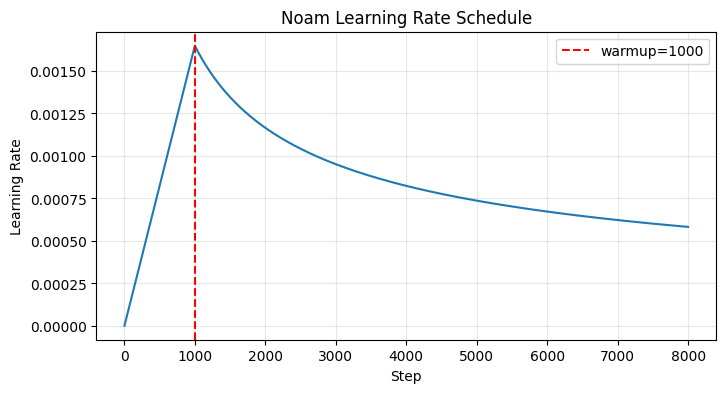

In [ ]:
# ==========================================
# 6-4-3: Learning Rate 곡선 확인
# ==========================================

import matplotlib.pyplot as plt

steps = range(1, 8000)
lrs = [lr_scheduler(s) for s in steps]

plt.figure(figsize=(8, 4))
plt.plot(steps, lrs)
plt.axvline(WARMUP_STEPS, color='r', linestyle='--', label=f'warmup={WARMUP_STEPS}')
plt.xlabel('Step')
plt.ylabel('Learning Rate')
plt.title('Noam Learning Rate Schedule')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 6-5 Loss Function

In [ ]:
# ==========================================
# 6-5: Loss Function (패딩 마스킹)
# ==========================================
# 핵심: <pad>(=0) 위치는 loss 계산에서 제외!
#   - 패딩은 의미 없는 채움 → 학습에 반영하면 안 됨
#   - 실제 토큰 위치만 평균 내서 정확한 loss
# ==========================================

import torch.nn.functional as F

def loss_function(real, pred):
    """
    real : [batch, seq_len]            정답 토큰 인덱스
    pred : [batch, seq_len, vocab]     모델 출력 logits
    """
    real = real.to(device)
    pred = pred.to(device)

    # 1) 위치별 cross-entropy (reduction='none' → 각각 따로)
    loss_ = F.cross_entropy(
        pred.contiguous().view(-1, pred.size(-1)),   # [batch*seq, vocab]
        real.contiguous().view(-1),                  # [batch*seq]
        reduction='none'
    )
    # 다시 [batch, seq_len]로 복원
    loss_ = loss_.view(real.size())

    # 2) 패딩 마스크: real이 0(=<pad>)이 아닌 위치만 1
    mask = (real != PAD_ID).float()
    loss_ = loss_ * mask                # 패딩 위치 loss → 0

    # 3) 실제 토큰 수로 나눠 평균 (패딩 제외)
    return loss_.sum() / mask.sum()

print("loss_function 정의 완료")

loss_function 정의 완료


### 6-6 train_step 정의

```
┌────────────────────────
│ 1. model.train()       학습 모드 ON      
│ 2. zero_grad()         gradient 초기화   
│ 3. tgt 분리            입력/정답 나누기  
│ 4. generate_masks()    마스크 생성       
│ 5. model(...)          forward (예측)    
│ 6. loss_function()     손실 계산         
│ 7. loss.backward()     gradient 계산     
│ 8. optimizer.step()    파라미터 업데이트  
└────────────────────────
```

In [ ]:
# ==========================================
# 6-6: Train Step (배치 1개 학습)
# ==========================================
# 1 배치에 대해:
#   forward → loss 계산 → backward → 파라미터 업데이트
#
# Teacher Forcing:
#   tgt_in = tgt[:, :-1]  디코더 입력 (<start> ~ 끝-1)
#   gold   = tgt[:, 1:]   정답       (2번째 ~ <end>)
# ==========================================

def train_step(src, tgt, model, optimizer):
    model.train()                  # 학습 모드 (dropout 켜짐)
    optimizer.zero_grad()          # 이전 gradient 초기화

    # Teacher Forcing: 입력/정답 한 칸씩 밀기
    tgt_in = tgt[:, :-1]           # 디코더 입력
    gold   = tgt[:, 1:]            # 디코더 정답

    # 마스크 생성 (src, tgt_in 기준)
    enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_in)

    # device 이동
    src          = src.to(device)
    tgt_in       = tgt_in.to(device)
    enc_mask     = enc_mask.to(device)
    dec_enc_mask = dec_enc_mask.to(device)
    dec_mask     = dec_mask.to(device)

    # forward
    predictions, enc_attns, dec_attns, dec_enc_attns = model(
        src, tgt_in, enc_mask, dec_enc_mask, dec_mask
    )

    # loss 계산
    loss = loss_function(gold, predictions)

    # 역전파 + 파라미터 업데이트
    loss.backward()
    optimizer.step()

    return loss, enc_attns, dec_attns, dec_enc_attns

print("train_step 정의 완료")

train_step 정의 완료


### 6-7 학습 루프

#### 6-7-1 검증 함수

In [ ]:
# ==========================================
# Step 6-7-1: Validation 함수
# ==========================================
# 학습 X, loss만 계산 (과적합 모니터링용)
# ==========================================

@torch.no_grad()                    # gradient 계산 안 함 (메모리/속도 ↑)
def evaluate(model, loader):
    model.eval()                    # 평가 모드 (dropout 꺼짐)
    total_loss = 0.0

    for src, tgt in loader:
        tgt_in = tgt[:, :-1]
        gold   = tgt[:, 1:]

        enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_in)

        src          = src.to(device)
        tgt_in       = tgt_in.to(device)
        enc_mask     = enc_mask.to(device)
        dec_enc_mask = dec_enc_mask.to(device)
        dec_mask     = dec_mask.to(device)

        predictions, *_ = model(src, tgt_in, enc_mask, dec_enc_mask, dec_mask)
        loss = loss_function(gold, predictions)
        total_loss += loss.item()

    return total_loss / len(loader)

print("evaluate 정의 완료")

evaluate 정의 완료


#### 6-7-2 학습 루프

- Epoch 10 : 최종 Train Loss: 3.9171, Val Loss  : 3.8920  
- Epoch 30 : 최종 Train Loss: 2.6517, Val Loss  : 3.0169
- Epoch 50 : 최종 Train Loss: 1.8340  Val Loss  : 2.4527

In [ ]:
# ==========================================
# 6-7-2: 학습 루프
# ==========================================
# - 매 step마다 Noam LR 갱신
# - 매 epoch마다 train/val loss 출력
# - val loss 최저 시 모델 저장 (best model)
# ==========================================

from tqdm.notebook import tqdm

# EPOCHS = 50  # 10 -> 30(Train: 2.6999 | Val: 3.0424) -> 50  => 1단계
# 10 -> 50 (과적합) -> 20
EPOCHS = 20  # 10 (Train Loss: 2.3647 / Val Loss  : 2.8970) -> 50(Train Loss: 0.7365 / Val Loss  : 1.0840)
global_step = 0
best_val_loss = float('inf')
history = {'train': [], 'val': []}

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0
    tqdm_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for src, tgt in tqdm_bar:
        global_step += 1

        #  Noam LR 갱신 (매 step)
        lr = lr_scheduler(global_step)
        for param_group in optimizer.param_groups:
            param_group['lr'] = lr

        # 학습
        loss, *_ = train_step(src, tgt, model, optimizer)
        total_loss += loss.item()

        tqdm_bar.set_postfix({
            'loss': f"{loss.item():.4f}",
            'lr': f"{lr:.2e}"
        })

    train_loss = total_loss / len(train_loader)
    val_loss = evaluate(model, val_loader)
    history['train'].append(train_loss)
    history['val'].append(val_loss)

    print(f"Epoch {epoch+1:2d} | Train: {train_loss:.4f} | Val: {val_loss:.4f}", end="")

    # best 모델 저장
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), f'{MODEL_DIR}/best_model.pt')
        print("  ← best 저장 ")
    else:
        print()

print(f"\n학습 완료! Best Val Loss: {best_val_loss:.4f}")

Epoch 1/20:   0%|          | 0/490 [00:00<?, ?it/s]

Epoch  1 | Train: 96.9130 | Val: 8.8088  ← best 저장 


Epoch 2/20:   0%|          | 0/490 [00:00<?, ?it/s]

Epoch  2 | Train: 8.5253 | Val: 4.5010  ← best 저장 


Epoch 3/20:   0%|          | 0/490 [00:00<?, ?it/s]

...

Epoch 18 | Train: 2.1726 | Val: 3.1882


Epoch 19/20:   0%|          | 0/490 [00:00<?, ?it/s]

Epoch 19 | Train: 2.1032 | Val: 3.1728  ← best 저장 


Epoch 20/20:   0%|          | 0/490 [00:00<?, ?it/s]

Epoch 20 | Train: 2.0371 | Val: 3.1825

학습 완료! Best Val Loss: 3.1728


#### 6-7-3 학습 곡선(Loss 시각화)

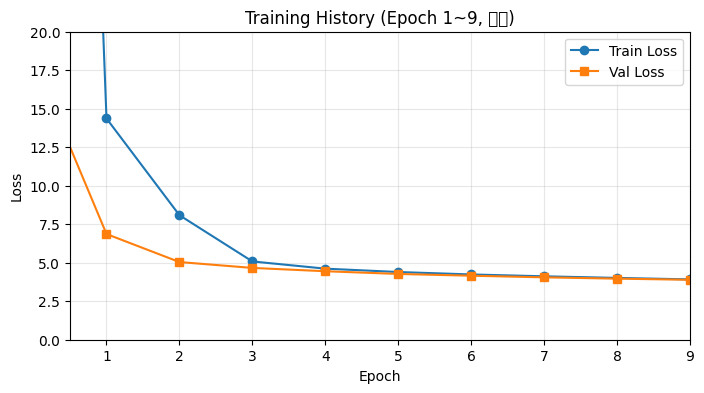

In [ ]:
# ==========================================
# 6-7-3: Loss 곡선 시각화 (10 epoch)
# ==========================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(history['train'], 'o-', label='Train Loss')
plt.plot(history['val'], 's-', label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training History (Epoch 1~9)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 20)              # ← y축 0~20으로 제한
plt.xlim(0.5, 9)             # ← epoch 0 제외
plt.show()

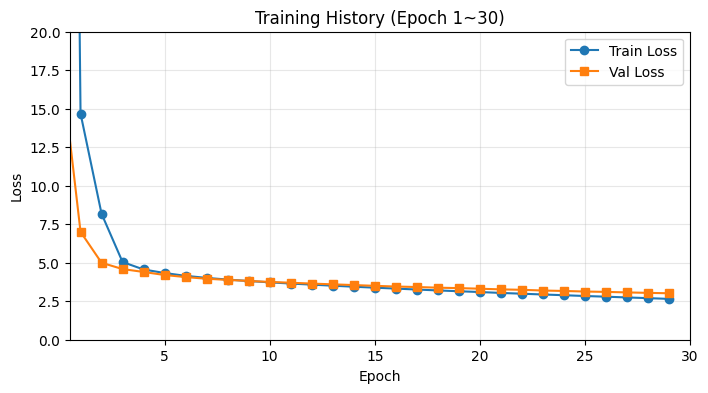

In [ ]:
# ==========================================
# 6-7-3: Loss 곡선 시각화  (50 epoch)
# ==========================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(history['train'], 'o-', label='Train Loss')
plt.plot(history['val'], 's-', label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training History (Epoch 1~30)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 20)              # ← y축 0~20으로 제한
plt.xlim(0.5, 30)             # ← epoch 0 제외
plt.show()

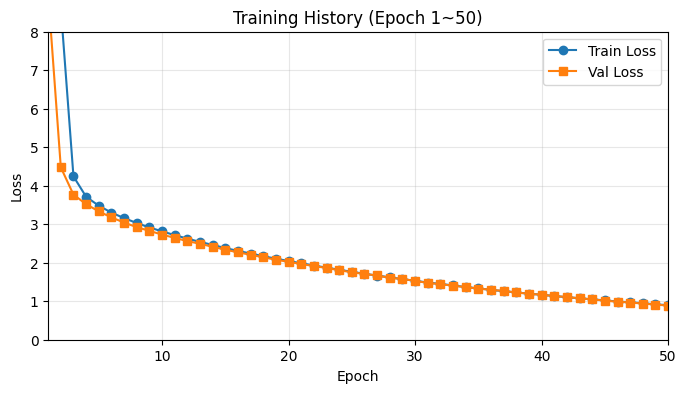

In [ ]:
# ==========================================
# 6-7-3: Loss 곡선 시각화  (50 epoch)
# ==========================================

import matplotlib.pyplot as plt

epochs = range(1, len(history['train']) + 1)

plt.figure(figsize=(8, 4))
plt.plot(epochs, history['train'], 'o-', label='Train Loss')
plt.plot(epochs, history['val'], 's-', label='Val Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title(f'Training History (Epoch 1~{len(history["train"])})')

plt.legend()
plt.grid(True, alpha=0.3)

# 첫 epoch loss가 너무 커서 뒤쪽 변화가 눌려 보이면 y축을 제한
plt.ylim(0, 8)

# 실제 학습 epoch 수에 맞춰 x축 설정
plt.xlim(1, len(history['train']))

plt.show()


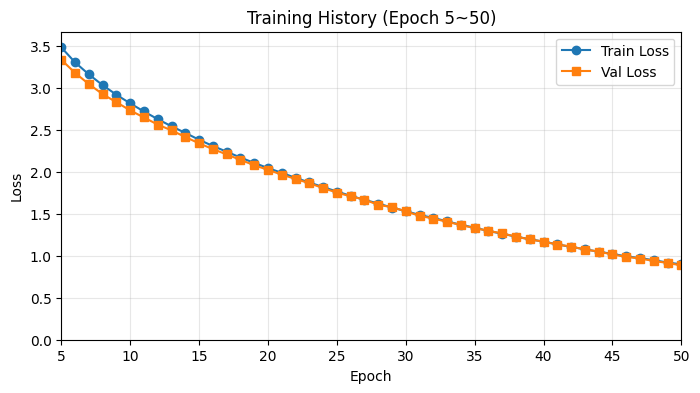

In [ ]:
# ==========================================
# 후반부 Loss 곡선 확대
# ==========================================

start_epoch = 5
epochs = range(1, len(history['train']) + 1)

plt.figure(figsize=(8, 4))
plt.plot(epochs, history['train'], 'o-', label='Train Loss')
plt.plot(epochs, history['val'], 's-', label='Val Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title(f'Training History (Epoch {start_epoch}~{len(history["train"])})')

plt.legend()
plt.grid(True, alpha=0.3)

plt.xlim(start_epoch, len(history['train']))
plt.ylim(0, max(history['val'][start_epoch-1:]) * 1.1)

plt.show()


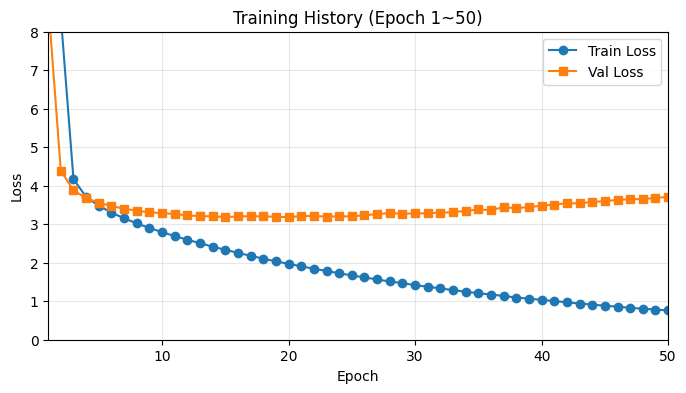

In [ ]:
# ==========================================
# 6-7-3: Loss 곡선 시각화  (50 epoch)
# ==========================================

import matplotlib.pyplot as plt

epochs = range(1, len(history['train']) + 1)

plt.figure(figsize=(8, 4))
plt.plot(epochs, history['train'], 'o-', label='Train Loss')
plt.plot(epochs, history['val'], 's-', label='Val Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title(f'Training History (Epoch 1~{len(history["train"])})')

plt.legend()
plt.grid(True, alpha=0.3)

# 첫 epoch loss가 너무 커서 뒤쪽 변화가 눌려 보이면 y축을 제한
plt.ylim(0, 8)

# 실제 학습 epoch 수에 맞춰 x축 설정
plt.xlim(1, len(history['train']))

plt.show()

- 3단계 epoch 50에서 과적합 발생
  - epoch 20으로 변경함.

In [ ]:
print(f"최종 Train Loss: {history['train'][-1]:.4f}")
print(f"최종 Val Loss  : {history['val'][-1]:.4f}")
print(f"Best Val Loss  : {best_val_loss:.4f}")

import os
print(f"\nbest_model.pt 저장됨: {os.path.exists(f'{MODEL_DIR}/best_model.pt')}")

# 30 Epoch 결과
# 최종 Train Loss: 3.9171
# 최종 Val Loss  : 3.8920
# Best Val Loss  : 3.8920

최종 Train Loss: 1.5417
최종 Val Loss  : 3.0763
Best Val Loss  : 3.0234

best_model.pt 저장됨: True


In [ ]:
model.load_state_dict(torch.load(f'{MODEL_DIR}/best_model.pt', map_location=device))
model.eval()


Transformer(
  (enc_emb): Embedding(7553, 368)
  (dec_emb): Embedding(7553, 368)
  (do): Dropout(p=0.2, inplace=False)
  (encoder): Encoder(
    (enc_layers): ModuleList(
      (0): EncoderLayer(
        (enc_self_attn): MultiHeadAttention(
          (W_q): Linear(in_features=368, out_features=368, bias=True)
          (W_k): Linear(in_features=368, out_features=368, bias=True)
          (W_v): Linear(in_features=368, out_features=368, bias=True)
          (linear): Linear(in_features=368, out_features=368, bias=True)
        )
        (ffn): PoswiseFeedForwardNet(
          (fc1): Linear(in_features=368, out_features=1024, bias=True)
          (fc2): Linear(in_features=1024, out_features=368, bias=True)
          (relu): ReLU()
        )
        (norm_1): LayerNorm((368,), eps=1e-06, elementwise_affine=True)
        (norm_2): LayerNorm((368,), eps=1e-06, elementwise_affine=True)
        (do): Dropout(p=0.2, inplace=False)
      )
    )
    (final_norm): LayerNorm((368,), eps=1e-06, el

### 6-8 chat 함수

In [ ]:
# ==========================================
# 6-8: 추론 함수 (Greedy Decoding)
# ==========================================
# 동작:
#   1. 질문 → MeCab 토큰화 → 정수 인코딩 → 패딩
#   2. 디코더에 <start>부터 시작
#   3. 한 토큰씩 생성 (argmax)
#   4. <end> 나오면 종료
# ==========================================

import torch

def chat(question, model, max_len=20):
    """
    question : 사용자 질문 (문자열)
    return   : 챗봇 답변 (문자열)
    """
    model.eval()

    # --- 1) 질문 전처리 + 토큰화 + 인코딩 ---
    q_clean = preprocess_sentence(question)
    q_tokens = mecab.morphs(q_clean)
    q_ids = [word2idx.get(t, UNK_ID) for t in q_tokens]

    # 패딩 (max_len 고정)
    if len(q_ids) > max_len:
        q_ids = q_ids[:max_len]
    else:
        q_ids = q_ids + [PAD_ID] * (max_len - len(q_ids))

    src = torch.tensor([q_ids], dtype=torch.long, device=device)  # [1, max_len]

    # --- 2) 디코더 첫 입력: <start> ---
    dec_input = torch.tensor([[START_ID]], dtype=torch.long, device=device)

    result_ids = []

    # --- 3) 한 토큰씩 생성 ---
    for _ in range(max_len):
        enc_mask, dec_enc_mask, dec_mask = generate_masks(src, dec_input)

        with torch.no_grad():
            predictions, *_ = model(src, dec_input, enc_mask, dec_enc_mask, dec_mask)

        # 마지막 위치의 예측 → 가장 확률 높은 토큰
        next_id = predictions[0, -1].argmax(dim=-1).item()

        # <end> 만나면 종료
        if next_id == END_ID:
            break

        result_ids.append(next_id)

        # 생성한 토큰을 디코더 입력에 이어붙임
        next_token = torch.tensor([[next_id]], dtype=torch.long, device=device)
        dec_input = torch.cat([dec_input, next_token], dim=1)

    # --- 4) 정수 → 단어 복원 ---
    answer = ' '.join([idx2word[i] for i in result_ids])
    return answer

print("chat 함수 정의 완료")

chat 함수 정의 완료


In [ ]:
# 간단 테스트
test_q = "오늘 너무 피곤해"
print(f"[Q] {test_q}")
print(f"[A] {chat(test_q, model)}")

[Q] 오늘 너무 피곤해
[A] 요즘 쉬 세요 .


In [ ]:
target = ['오늘', '너무', '피곤', '해']

print("=== que_final / ans_final에서 target 찾기 ===")

found = 0
for i, (q, a) in enumerate(zip(que_final, ans_final)):
    if q == target:
        print("index:", i)
        print("Q:", q)
        print("A:", a)
        print("A ids:", dec_train[i])
        found += 1

print("found:", found)


=== que_final / ans_final에서 target 찾기 ===
index: 2979
Q: ['오늘', '너무', '피곤', '해']
A: ['푹', '쉬', '세요', '.']
A ids: [1206, 226, 9, 4]
index: 13416
Q: ['오늘', '너무', '피곤', '해']
A: ['푹', '쉬', '세요', '.']
A ids: [1206, 226, 9, 4]
found: 2


In [ ]:
# 확인용
for i in range(5):
    print(ans_final[i][:10])
    print("start 개수:", ans_final[i].count("<start>"))
    print("end 개수  :", ans_final[i].count("<end>"))
    print()

['<start>', '사탕', '만들', '어요', '.', '<end>']
start 개수: 1
end 개수  : 1

['<start>', '육아', '파이팅', '!', '!', '<end>']
start 개수: 1
end 개수  : 1

['<start>', '몸', '과', '마음', '이', '좀', '쉬', '어야', '할', '것']
start 개수: 1
end 개수  : 1

['<start>', '헤어짐', '에', '도', '처', '방약', '이', '있', '으면', '좋']
start 개수: 1
end 개수  : 1

['<start>', '생각', '을', '정리', '해', '보', '세요', '.', '<end>']
start 개수: 1
end 개수  : 1



### 6-9 제출 예문 4개 테스트

In [ ]:
# ==========================================
# Step 6-9: 노트북 지정 예문 4개 테스트
# ==========================================

test_examples = [
    "지루하다, 놀러가고 싶어.",
    "오늘 일찍 일어났더니 피곤하다.",
    "간만에 여자친구랑 데이트 하기로 했어.",
    "집에 있는다는 소리야."
]

print("=" * 50)
print("챗봇 응답 테스트 (제출용)")
print("=" * 50)
for i, q in enumerate(test_examples, 1):
    answer = chat(q, model)
    print(f"\n{i}. [Q] {q}")
    print(f"   [A] {answer}")
print("\n" + "=" * 50)

챗봇 응답 테스트 (제출용)

1. [Q] 지루하다, 놀러가고 싶어.
   [A] 저 도 좋 은 여행 도 좋 아 할 수 있 어요 .

2. [Q] 오늘 일찍 일어났더니 피곤하다.
   [A] 오늘 은 힘내 지 않 아요 .

3. [Q] 간만에 여자친구랑 데이트 하기로 했어.
   [A] 좋 은 친구 가 좋 은 친구 가 좋 은 친구 가 좋 은 친구 가 좋 은 친구 가

4. [Q] 집에 있는다는 소리야.
   [A] 생각 보다 좋 은 생각 을 거 예요 .



- **1단계 예문 결과 (최종선택)**
```
==================================================
챗봇 응답 테스트 (제출용) - Greedy Decoding
==================================================
1. [Q] 지루하다, 놀러가고 싶어.
   [A] 같이 놀 러 가 세요 !

2. [Q] 오늘 일찍 일어났더니 피곤하다.
   [A] 저 도 고민 이 깊 죠 .

3. [Q] 간만에 여자친구랑 데이트 하기로 했어.
   [A] 친구 가 좋 아 하 면 좋 을 거 예요 .

4. [Q] 집에 있는다는 소리야.
   [A] 당분간 은 아닌가요 .
==================================================

==================================================
Greedy Decoding  Vs  Beam Search Decoding
==================================================
1. [Q]      지루하다, 놀러가고 싶어.
   [Greedy] 같이 놀 러 가 세요 !
   [Beam]   같이 놀 러 가 세요 !

2. [Q]      오늘 일찍 일어났더니 피곤하다.
   [Greedy] 저 도 고민 이 깊 죠 .
   [Beam]   저 도 놀 고 싶 어요 .

3. [Q]      간만에 여자친구랑 데이트 하기로 했어.
   [Greedy] 친구 가 좋 아 하 면 좋 을 거 예요 .
   [Beam]   같이 운동 해 주 세요 .

4. [Q]      집에 있는다는 소리야.
   [Greedy] 당분간 은 아닌가요 .
   [Beam]   당분간 에 집중 하 세요 .

=================================================

Hyperparameters
> n_layers    : 1
> d_model     : 368
> n_heads     : 8
> d_ff        : 1024
> dropout     : 0.2

Training Parameters
> Warmup Steps : 1000
> Batch Size   : 64
> Epoch At     : 50
> Train Data   : 20,592쌍
> Val Data     : 약 2,289쌍

BLEU Score
> Greedy       : 0.3650 (샘플 500)
> Beam Search  : 0.4057 (샘플 300)
```

- **2단계 예문 결과**
```
==================================================
챗봇 응답 테스트 (제출용)
==================================================

1. [Q] 지루하다, 놀러가고 싶어.
   [A] 제 가 왔 나 봐요 .

2. [Q] 오늘 일찍 일어났더니 피곤하다.
   [A] 맛있 게 먹 고 많이 했 나 봐요 .

3. [Q] 간만에 여자친구랑 데이트 하기로 했어.
   [A] 아이구 .

4. [Q] 집에 있는다는 소리야.
   [A] 나 봐요 .
==================================================

Hyperparameters
> n_layers : 1
> d_model  : 368
> n_heads  : 8
> d_ff     : 1024
> dropout  : 0.2

Training Parameters
> Warmup Steps : 1000
> Batch Size   : 64
> Epoch At     : 50
> Train Data   : 34,791쌍
> Val Data     : 약 3,479쌍
```

- **3단계 예문 결과**
```
==================================================
챗봇 응답 테스트 (제출용)
==================================================
1. [Q] 지루하다, 놀러가고 싶어.
   [A] 저 도 좋 은 여행 도 좋 아 할 수 있 어요 .

2. [Q] 오늘 일찍 일어났더니 피곤하다.
   [A] 오늘 은 힘내 지 않 아요 .

3. [Q] 간만에 여자친구랑 데이트 하기로 했어.
   [A] 좋 은 친구 가 좋 은 친구 가 좋 은 친구 가 좋 은 친구 가 좋 은 친구 가

4. [Q] 집에 있는다는 소리야.
   [A] 생각 보다 좋 은 생각 을 거 예요 .
==================================================

==================================================
Greedy Decoding  Vs  Beam Search Decoding
==================================================
1. [Q]      지루하다, 놀러가고 싶어.
   [Greedy] 저 도 좋 은 여행 도 좋 아 할 수 있 어요 .
   [Beam]   저 도 좋 아 할 수 있 어요 .

2. [Q]      오늘 일찍 일어났더니 피곤하다.
   [Greedy] 오늘 은 힘내 지 않 아요 .
   [Beam]   힘내 세요 .

3. [Q]      간만에 여자친구랑 데이트 하기로 했어.
   [Greedy] 좋 은 친구 가 좋 은 친구 가 좋 은 친구 가 좋 은 친구 가 좋 은 친구 가
   [Beam]   좋 아 하 는 게 좋 겠 네요 .

4. [Q]      집에 있는다는 소리야.
   [Greedy] 생각 보다 좋 은 생각 을 거 예요 .
   [Beam]   쉬운 일 이 아니 에요 .
==================================================

Hyperparameters
> n_layers : 1
> d_model  : 368
> n_heads  : 8
> d_ff     : 1024
> dropout  : 0.2

Training Parameters
> Warmup Steps : 1000
> Batch Size   : 64
> Epoch At     : 20
> Train Data   : 31,311쌍
> Val Data     : 1,160쌍

BLEU Score
> Greedy : 0.1231 (샘플 500)
> Beam Search : 0.1554 (샘플 300)
```

## Step 7 성능 측정하기 BLEU Score

### 7-1 BLEU Score

In [ ]:
# ==========================================
# 7-1: BLEU Score 함수
# ==========================================
# BLEU: 생성 답변과 정답 답변의 n-gram 겹침 정도 (0~1)
# smoothing: 짧은 문장에서 0 되는 것 방지
# ==========================================

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

def calculate_bleu(reference, candidate, weights=(0.25, 0.25, 0.25, 0.25)):
    """
    reference : 정답 토큰 리스트  예) ['하루', '가', '또', ...]
    candidate : 생성 토큰 리스트
    """
    return sentence_bleu(
        [reference],
        candidate,
        weights=weights,
        smoothing_function=SmoothingFunction().method1
    )

print("calculate_bleu 정의 완료")

calculate_bleu 정의 완료


###  7-2 토큰 리스트로 답변 생성하는 헬퍼

In [ ]:
# ==========================================
# 7-2: 토큰 리스트 입력용 chat (BLEU 평가용)
# ==========================================
# 기존 chat()은 문자열 입력 → 평가는 이미 토큰화된
# que_corpus를 쓰므로 토큰 직접 받는 버전 필요
# ==========================================

@torch.no_grad()
def chat_from_tokens(q_tokens, model, max_len=20):
    model.eval()

    q_ids = [word2idx.get(t, UNK_ID) for t in q_tokens]
    if len(q_ids) > max_len:
        q_ids = q_ids[:max_len]
    else:
        q_ids = q_ids + [PAD_ID] * (max_len - len(q_ids))

    src = torch.tensor([q_ids], dtype=torch.long, device=device)
    dec_input = torch.tensor([[START_ID]], dtype=torch.long, device=device)

    result_ids = []
    for _ in range(max_len):
        enc_mask, dec_enc_mask, dec_mask = generate_masks(src, dec_input)
        predictions, *_ = model(src, dec_input, enc_mask, dec_enc_mask, dec_mask)
        next_id = predictions[0, -1].argmax(dim=-1).item()
        if next_id == END_ID:
            break
        result_ids.append(next_id)
        next_token = torch.tensor([[next_id]], dtype=torch.long, device=device)
        dec_input = torch.cat([dec_input, next_token], dim=1)

    return [idx2word[i] for i in result_ids]   # 토큰 리스트 반환

print("chat_from_tokens 정의 완료")

chat_from_tokens 정의 완료


### 7-3: 단일 문장 BLEU

In [ ]:
# ==========================================
# 7-3: 한 문장 BLEU 확인
# ==========================================

def eval_bleu_single(idx, model, verbose=True):
    q_tokens = que_corpus[idx]              # 질문 토큰
    ref      = ans_corpus[idx]              # 정답 토큰
    cand     = chat_from_tokens(q_tokens, model)   # 생성 토큰

    score = calculate_bleu(ref, cand)

    if verbose:
        print(f"[Q  ] {' '.join(q_tokens)}")
        print(f"[정답] {' '.join(ref)}")
        print(f"[생성] {' '.join(cand)}")
        print(f"[BLEU] {score:.4f}\n")
    return score

# 샘플 5개 테스트
for i in range(5):
    eval_bleu_single(i, model)

[Q  ] 12 시 땡 !
[정답] 하루 가 또 가 네요 .
[생성] 맛있 는 거 드세요 .
[BLEU] 0.0440

[Q  ] 1 지망 학교 떨어졌 어
[정답] 위로 해 드립니다 .
[생성] 친구 를 해 보 세요 .
[BLEU] 0.0485

[Q  ] 3 박 4 일 놀 러 가 고 싶 다
[정답] 여행 은 언제나 좋 죠 .
[생성] 여행 을 때 가 있 죠 .
[BLEU] 0.0773

[Q  ] 3 박 4 일 정도 놀 러 가 고 싶 다
[정답] 여행 은 언제나 좋 죠 .
[생성] 여행 을 때 가 있 죠 .
[BLEU] 0.0773

[Q  ] ppl 심하 네
[정답] 눈살 이 찌푸려 지 죠 .
[생성] 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이
[BLEU] 0.0000



### 7-4 전체 평균 BLEU

In [ ]:
# ==========================================
# 7-4: 전체 BLEU 평균 (샘플링)
# ==========================================
# 전체 다 돌면 오래 걸리므로 일부만 (예: 500개)
# ==========================================

from tqdm.notebook import tqdm
import random

random.seed(42)
sample_size = 500
indices = random.sample(range(len(que_corpus)), sample_size)

total = 0.0
for idx in tqdm(indices, desc="BLEU 평가"):
    total += eval_bleu_single(idx, model, verbose=False)

avg_bleu = total / sample_size
print(f"\n샘플 수    : {sample_size}")
print(f"평균 BLEU  : {avg_bleu:.4f}")

BLEU 평가:   0%|          | 0/500 [00:00<?, ?it/s]


샘플 수    : 500
평균 BLEU  : 0.1554


- 1단계

 ### 7-5 Beam Search Decoder

In [ ]:
# ==========================================
# 7-5: Beam Search Decoder
# ==========================================
# Greedy: 매 step 1등만 → 지역 최적, 반복 잘 생김
# Beam  : 매 step 상위 k개 후보 유지 → 문장 전체로 최선 선택
#
# 점수: log 확률 누적합 (곱셈 대신 덧셈 → 안정적)
# 길이 정규화: 짧은 문장 편향 방지
# ==========================================

import torch
import torch.nn.functional as F

@torch.no_grad()
def chat_beam(q_tokens, model, beam_size=5, max_len=20, alpha=0.7):
    """
    q_tokens  : 질문 토큰 리스트
    beam_size : 유지할 후보 수
    alpha     : 길이 정규화 강도 (0=없음, 1=강함)
    return    : 생성 토큰 리스트 (최고 점수)
    """
    model.eval()

    # 질문 인코딩 + 패딩
    q_ids = [word2idx.get(t, UNK_ID) for t in q_tokens]
    if len(q_ids) > max_len:
        q_ids = q_ids[:max_len]
    else:
        q_ids = q_ids + [PAD_ID] * (max_len - len(q_ids))
    src = torch.tensor([q_ids], dtype=torch.long, device=device)

    # 초기 beam: (시퀀스, 누적 log확률, 종료여부)
    beams = [([START_ID], 0.0, False)]

    for _ in range(max_len):
        new_beams = []

        for seq, score, finished in beams:
            # 이미 끝난 beam은 그대로 유지
            if finished:
                new_beams.append((seq, score, True))
                continue

            dec_input = torch.tensor([seq], dtype=torch.long, device=device)
            enc_mask, dec_enc_mask, dec_mask = generate_masks(src, dec_input)
            predictions, *_ = model(src, dec_input, enc_mask, dec_enc_mask, dec_mask)

            # 마지막 위치 → log 확률
            log_probs = F.log_softmax(predictions[0, -1], dim=-1)

            # 상위 beam_size개 후보 토큰
            topk_lp, topk_id = log_probs.topk(beam_size)

            for lp, tid in zip(topk_lp.tolist(), topk_id.tolist()):
                new_seq = seq + [tid]
                new_score = score + lp
                is_end = (tid == END_ID)
                new_beams.append((new_seq, new_score, is_end))

        # 길이 정규화 점수로 상위 beam_size개만 유지
        def norm_score(item):
            seq, sc, _ = item
            length = len(seq)
            return sc / (length ** alpha)

        new_beams.sort(key=norm_score, reverse=True)
        beams = new_beams[:beam_size]

        # 모든 beam이 종료되면 중단
        if all(b[2] for b in beams):
            break

    # 최고 점수 beam 선택
    best_seq = beams[0][0]

    # <start>, <end> 제거 후 단어 복원
    result = []
    for tid in best_seq:
        if tid == START_ID:
            continue
        if tid == END_ID:
            break
        result.append(idx2word[tid])
    return result

print("chat_beam 정의 완료")

chat_beam 정의 완료


### 7-6 Greedy vs Beam 비교

In [ ]:
# ==========================================
# 7-6: 예문 4개 - Greedy vs Beam 비교
# ==========================================

test_examples = [
    "지루하다, 놀러가고 싶어.",
    "오늘 일찍 일어났더니 피곤하다.",
    "간만에 여자친구랑 데이트 하기로 했어.",
    "집에 있는다는 소리야."
]

print("=" * 60)
for i, q in enumerate(test_examples, 1):
    q_clean = preprocess_sentence(q)
    q_tokens = mecab.morphs(q_clean)

    greedy_ans = ' '.join(chat_from_tokens(q_tokens, model))
    beam_ans   = ' '.join(chat_beam(q_tokens, model, beam_size=5))

    print(f"{i}. [Q]      {q}")
    print(f"   [Greedy] {greedy_ans}")
    print(f"   [Beam]   {beam_ans}")
    print()
print("=" * 60)

1. [Q]      지루하다, 놀러가고 싶어.
   [Greedy] 저 도 좋 은 여행 도 좋 아 할 수 있 어요 .
   [Beam]   저 도 좋 아 할 수 있 어요 .

2. [Q]      오늘 일찍 일어났더니 피곤하다.
   [Greedy] 오늘 은 힘내 지 않 아요 .
   [Beam]   힘내 세요 .

3. [Q]      간만에 여자친구랑 데이트 하기로 했어.
   [Greedy] 좋 은 친구 가 좋 은 친구 가 좋 은 친구 가 좋 은 친구 가 좋 은 친구 가
   [Beam]   좋 아 하 는 게 좋 겠 네요 .

4. [Q]      집에 있는다는 소리야.
   [Greedy] 생각 보다 좋 은 생각 을 거 예요 .
   [Beam]   쉬운 일 이 아니 에요 .



```
1단계
============================================================
1. [Q]      지루하다, 놀러가고 싶어.
   [Greedy] 같이 놀 러 가 세요 !
   [Beam]   같이 놀 러 가 세요 !

2. [Q]      오늘 일찍 일어났더니 피곤하다.
   [Greedy] 저 도 고민 이 깊 죠 .
   [Beam]   저 도 놀 고 싶 어요 .

3. [Q]      간만에 여자친구랑 데이트 하기로 했어.
   [Greedy] 친구 가 좋 아 하 면 좋 을 거 예요 .
   [Beam]   같이 운동 해 주 세요 .

4. [Q]      집에 있는다는 소리야.
   [Greedy] 당분간 은 아닌가요 .
   [Beam]   당분간 에 집중 하 세요 .

============================================================

```

### 7-7 Beam BLEU 평가

In [ ]:
# ==========================================
# Step 7-7: Beam Search BLEU 평균
# ==========================================

from tqdm.notebook import tqdm
import random

random.seed(42)
sample_size = 300   # beam은 느려서 샘플 줄임
indices = random.sample(range(len(que_corpus)), sample_size)

total = 0.0
for idx in tqdm(indices, desc="Beam BLEU"):
    ref  = ans_corpus[idx]
    cand = chat_beam(que_corpus[idx], model, beam_size=5)
    total += calculate_bleu(ref, cand)

print(f"\n샘플 수      : {sample_size}")
print(f"Beam 평균 BLEU: {total / sample_size:.4f}")

Beam BLEU:   0%|          | 0/300 [00:00<?, ?it/s]


샘플 수      : 300
Beam 평균 BLEU: 0.1782


```
# 예문
1. 지루하다, 놀러가고 싶어.
2. 오늘 일찍 일어났더니 피곤하다.
3. 간만에 여자친구랑 데이트 하기로 했어.
4. 집에 있는다는 소리야.

---

# 제출

Translations
> 1. 잠깐 쉬 어도 돼요 . <end>
> 2. 맛난 거 드세요 . <end>
> 3. 떨리 겠 죠 . <end>
> 4. 좋 아 하 면 그럴 수 있 어요 . <end>

Hyperparameters
> n_layers: 1
> d_model: 368
> n_heads: 8
> d_ff: 1024
> dropout: 0.2

Training Parameters
> Warmup Steps: 1000
> Batch Size: 64
> Epoch At: 10
```

In [ ]:
with open('/kaggle/working/submission.txt', 'w', encoding='utf-8') as f:
    f.write("""=== 멋진 챗봇 만들기 - 최종 제출 ===

Translations (Beam Search, beam_size=5)
1. 같이 놀 러 가 세요 !
2. 저 도 놀 고 싶 어요 .
3. 같이 운동 해 주 세요 .
4. 당분간 에 집중 하 세요 .

Hyperparameters: n_layers=1, d_model=368, n_heads=8, d_ff=1024, dropout=0.2
Training: Epoch=50, Batch=64, Warmup=1000, Best Val Loss=2.4527
BLEU: Greedy=0.3650, Beam=0.4057
""")
print("submission.txt 저장 완료")

submission.txt 저장 완료


In [ ]:
print("=== 학습 데이터 샘플 응답 확인 ===")

for i in range(10):
    q = " ".join(que_corpus[i])
    ref = " ".join(ans_corpus[i])
    pred = chat(q, model)

    print(f"\n[{i}]")
    print(f"Q   : {q}")
    print(f"REF : {ref}")
    print(f"PRED: {pred}")

=== 학습 데이터 샘플 응답 확인 ===

[0]
Q   : 12 시 땡 !
REF : 하루 가 또 가 네요 .
PRED: 맛있 는 거 드세요 .

[1]
Q   : 1 지망 학교 떨어졌 어
REF : 위로 해 드립니다 .
PRED: 친구 를 해 보 세요 .

[2]
Q   : 3 박 4 일 놀 러 가 고 싶 다
REF : 여행 은 언제나 좋 죠 .
PRED: 여행 을 때 가 있 죠 .

[3]
Q   : 3 박 4 일 정도 놀 러 가 고 싶 다
REF : 여행 은 언제나 좋 죠 .
PRED: 여행 을 때 가 있 죠 .

[4]
Q   : ppl 심하 네
REF : 눈살 이 찌푸려 지 죠 .
PRED: 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이

[5]
Q   : sd 카드 망가졌 어
REF : 다시 새로 사 는 게 마음 편해요 .
PRED: 공부 는 일 이 있 는 거 예요 .

[6]
Q   : sd 카드 안 돼
REF : 다시 새로 사 는 게 마음 편해요 .
PRED: 눈 을 감 고 오 는 연습 을 해 보 세요 .

[7]
Q   : sns 맞 팔 왜 안 하 지 ㅠㅠ
REF : 잘 모르 고 있 을 수 도 있 어요 .
PRED: 신경 쓰 고 있 나 봐요 .

[8]
Q   : sns 시간 낭비 인 거 아 는데 매일 하 는 중
REF : 시간 을 정하 고 해 보 세요 .
PRED: 시간 을 정하 고 해 보 세요 .

[9]
Q   : sns 시간 낭비 인데 자꾸 보 게 됨
REF : 시간 을 정하 고 해 보 세요 .
PRED: 시간 을 정하 고 해 보 세요 .


- 2단계 문제점
    - 문제는 모델이 일반화한 게 아니라 train/val에 섞인 비슷한 샘플을 외우고 있는 상태. 그래서 지금 제출 예문이 학습 데이터 표현과 조금만 달라도 적절한 답변으로 못 가고 있음.
    - safe_lexical_sub 증강이 “질문 의도 다양화”를 충분히 못 하고 있음.
    - 샘플에서도 대부분 증강 Q가 원본과 거의 같았었는데, 데이터는 3배가 됐지만 실제로는 상당수가 복제에 가까운 증강이어서 모델 입장에서는 “비슷한 문장 외우기”가 쉬워진 상태, 이것이 loss는 잘 내려가는데 새로운 표현에 약한 이유였음.
    - 이를 해결하기 위해 증강 강도 올려서 실험.

In [ ]:
# 쉬운 표현에서 어려운 표현으로 단계 테스트
probe_questions = [
    "오늘 너무 피곤해",
    "피곤해",
    "오늘 피곤해",
    "오늘 너무 피곤하다",
    "오늘 일찍 일어나서 피곤해",
    "오늘 일찍 일어났더니 피곤하다",
]

for q in probe_questions:
    print("[Q]", q)
    print("[TOKENS]", mecab.morphs(preprocess_sentence(q)))
    print("[A]", chat(q, model))
    print()

[Q] 오늘 너무 피곤해
[TOKENS] ['오늘', '너무', '피곤', '해']
[A] 푹 쉬 세요 .

[Q] 피곤해
[TOKENS] ['피곤', '해']
[A] 푹 쉬 세요 .

[Q] 오늘 피곤해
[TOKENS] ['오늘', '피곤', '해']
[A] 푹 쉬 세요 .

[Q] 오늘 너무 피곤하다
[TOKENS] ['오늘', '너무', '피곤', '하', '다']
[A] 푹 쉬 세요 .

[Q] 오늘 일찍 일어나서 피곤해
[TOKENS] ['오늘', '일찍', '일어나', '서', '피곤', '해']
[A] 맛있 는 거 드세요 .

[Q] 오늘 일찍 일어났더니 피곤하다
[TOKENS] ['오늘', '일찍', '일어났', '더니', '피곤', '하', '다']
[A] 맛있 는 거 드세요 .



In [ ]:
from sklearn.model_selection import train_test_split

# 현재 사용한 split과 같은 조건으로 토큰 데이터 기준 split 재현
que_tr_tokens, que_val_tokens, ans_tr_tokens, ans_val_tokens = train_test_split(
    que_final,
    ans_final,
    test_size=0.1,
    random_state=42
)

train_q_set = set(tuple(q) for q in que_tr_tokens)
val_q_set = set(tuple(q) for q in que_val_tokens)

overlap = train_q_set & val_q_set

print(f"Train 질문 unique 수: {len(train_q_set):,}")
print(f"Val 질문 unique 수  : {len(val_q_set):,}")
print(f"Train-Val 동일 질문 overlap 수: {len(overlap):,}")

print("\n=== 겹치는 질문 샘플 ===")
for q in list(overlap)[:20]:
    print(" ".join(q))



Train 질문 unique 수: 16,208
Val 질문 unique 수  : 3,240
Train-Val 동일 질문 overlap 수: 2,583

=== 겹치는 질문 샘플 ===
좋 아 하 는 여자 한테 표현 하 는 게 옳 은 걸까 ?
그냥 선 볼까 ?
말 할 때 너무 떨려
나 도 비키 니 입 고 싶 다
돈 모으 는 재미 가 있 네 .
코골이 어떻게 고쳐 ?
휴학 하 고 싶 다 .
뜻밖에 연락
사회 에서 도 좋 은 사람 만날 수 있 어 ?
3 달 이 지났 는데 이제야 헤어짐 을 확신 했 네
아빠 가 술 좀 그만 먹 었 으면
연애 처음 하 는 남자 친구
오늘 은 쉬 고 싶 다
이 쓰레기 야
정성 담긴 선물 뭐 가 좋 을까 ?
기운 이 없 어
짝 남 한테 크리스마스 선물 할 건데 추천 좀 .
과일 안 먹 게 돼
보 고 싶 은데
음 여기 다 말 해도 될까 모르 겠 다


In [ ]:
from sklearn.model_selection import train_test_split

n = len(que_corpus)
all_indices = list(range(len(que_final)))

idx_train, idx_val = train_test_split(
    all_indices,
    test_size=0.1,
    random_state=42
)

def group_id(idx):
    # 원본, 증강1, 증강2 모두 같은 원본 번호로 묶음
    return idx % n

train_groups = set(group_id(i) for i in idx_train)
val_groups = set(group_id(i) for i in idx_val)

group_overlap = train_groups & val_groups

print(f"원본 그룹 수              : {n:,}")
print(f"Train에 들어간 원본 그룹 수: {len(train_groups):,}")
print(f"Val에 들어간 원본 그룹 수  : {len(val_groups):,}")
print(f"Train-Val 그룹 overlap 수 : {len(group_overlap):,}")
print(f"Val 그룹 중 train에도 있는 비율: {len(group_overlap) / len(val_groups):.2%}")


원본 그룹 수              : 11,597
Train에 들어간 원본 그룹 수: 11,591
Val에 들어간 원본 그룹 수  : 3,145
Train-Val 그룹 overlap 수 : 3,139
Val 그룹 중 train에도 있는 비율: 99.81%


- 검증셋의 거의 모든 문장(2,583)이 train에 같은 원본 계열로 들어가 있어서 Val Loss 0.8853은 실제 일반화 성능이 아니라, 거의 같은 문제를 train에서 본 상태의 점수임.

## Step 8 추가 실험분석

### 8-1 Case 2. Q-only 3배 증강



- **변경 사항**
  - 기존에는 질문(Q)과 답변(A)을 모두 Word2Vec 유사어로 증강했다.
  - 실험 2에서는 답변(A)은 정답 데이터로 유지하고, 질문(Q)만 두 번 증강했다.
  - 데이터 구성은 다음과 같이 변경했다.
    - 원본 Q + 원본 A
    - 증강 Q1 + 원본 A
    - 증강 Q2 + 원본 A
  - 중복 제거 방식도 Q/A 개별 기준이 아니라 Q-A 쌍 기준으로 변경했다.
  - `safe_lexical_sub()`를 적용해 조사, 어미, 숫자, 문장부호, 한 글자 토큰 등은 치환하지 않도록 제한했다.

- **결과**
  - 원본 데이터 수   : 11,597쌍
  - 증강 후 데이터 수: 34,791쌍
  - Final Train Loss : 0.8978
  - Final Val Loss   : 0.8853
  - Best Val Loss    : 0.8853

- **분석**
  - 답변을 증강하지 않으면서 정답 문장이 깨지는 문제는 줄어들었다.
  - 손실값만 보면 성능이 크게 좋아진 것처럼 보였다.
  - 그러나 전체 데이터를 먼저 증강한 뒤 train/val로 나누었기 때문에, 같은 원본에서 파생된 문장이 train과 val에 동시에 들어갔다.
  - 실제 확인 결과, val 그룹 중 99.81%가 train에도 같은 원본 계열로 존재했다.
  - 따라서 낮은 val loss는 실제 일반화 성능이라기보다 데이터 누수의 영향을 받은 결과로 판단했다.


### 8-2 Case 3. Train 데이터만 Q-only 증강



- **변경 사항**
  - 실험 2의 데이터 누수를 줄이기 위해 원본 데이터를 먼저 train/val로 분리했다.
  - 이후 train 데이터에만 Q-only 증강을 적용했다.
  - val 데이터는 증강하지 않고 원본 그대로 유지했다.
  - vocab은 train 데이터 기준으로 생성했고, train/val을 각각 별도로 벡터화했다.
  - 기존 `train_test_split` 셀은 다시 split하지 않고, 이미 나눈 train/val 데이터를 DataLoader에 연결하도록 변경했다.

- **결과**
  - 원본 전체 데이터 수: 11,597쌍
  - Train 원본 데이터 수: 10,437쌍
  - Val 원본 데이터 수: 1,160쌍
  - 최종 Train 데이터 수: 31,311쌍
  - 최종 Val 데이터 수: 1,160쌍
  - Val `<unk>` 비율: 0.00%
  - 20 epoch 기준
    - Final Train Loss: 1.5417
    - Final Val Loss: 3.0763
    - Best Val Loss: 3.0234
  - 평균 BLEU: 0.1554

- **분석**
  - 실험 2보다 val loss는 높아졌지만, 이는 검증 데이터가 train과 독립적으로 분리되었기 때문에 더 정직한 평가로 볼 수 있다.
  - 50 epoch 실험에서는 epoch 20 이후 train loss는 계속 감소했지만 val loss는 상승했다.
  - 이를 통해 모델이 약 20 epoch 이후 과적합되는 경향을 확인했다.
  - 따라서 현재 설정에서는 20 epoch 전후가 더 적절한 학습량으로 판단했다.
  - 다만 응답 품질은 여전히 충분하지 않았다.
  - 증강 샘플을 확인한 결과 Word2Vec 치환이 의미를 훼손하는 사례가 있었다.
    - 고백 → 회개
    - 맥주 → 과자
    - 사람 → 백성
    - 외국인 → 한국인
  - 이런 경우 답변은 그대로인데 질문 의미가 바뀌므로 학습 데이터에 노이즈가 생긴다.




### 8-3 디코딩 비교



- **변경 사항**
- 기본 Greedy decoding과 Beam search decoding 결과를 비교했다.

- **결과**
- 3단계 테스트에서 Greedy decoding에서는 같은 구절이 반복되는 문제가 나타났다.
  - 예: `좋 은 친구 가 좋 은 친구 가 ...`
- Beam search를 적용하자 반복이 줄고 문장이 더 안정적으로 생성되었다.

- **분석**
- Greedy decoding은 매 시점 가장 높은 확률의 토큰만 선택하기 때문에, 한 번 반복 패턴에 빠지면 같은 구절을 계속 생성할 수 있다.
- Beam search는 여러 후보 문장을 유지하면서 전체 점수를 비교하므로 반복이 줄고 응답이 더 안정적이었다.
- 최종 응답 생성에는 Greedy보다 Beam search가 더 적절하다고 판단했다.


### 8-4 결론

초기 모델은 제출용 4개 예문에 대해 가장 자연스러운 응답을 보였기 때문에 최종 제출 결과로 사용했다. 그러나 이후 추가 실험을 통해 초기 방식에도 여러 한계가 있음을 확인했다.

실험 2에서는 답변 증강을 제거하고 Q-only 3배 증강을 적용해 정답 문장 오염을 줄였다. 하지만 전체 데이터를 증강한 뒤 train/val로 나누면서 데이터 누수가 발생했고, 낮은 val loss가 실제 일반화 성능을 의미하지 않을 수 있음을 확인했다.

실험 3에서는 train 데이터에만 증강을 적용해 검증 신뢰도를 높였다. 그 결과 val loss와 BLEU는 낮아졌지만, 이는 더 현실적인 평가 결과로 볼 수 있다. 또한 Word2Vec의 단어기준 유사성 기반 증강이 의미를 항상 보존하지 못해 학습 데이터에 노이즈를 만들 수 있다는 한계도 확인했다.

따라서 향후 추가 테스트 방향 셋은 다음과 같다.

- 답변(A)은 증강하지 않고 원본 정답으로 유지한다.
- train/val은 원본 기준으로 먼저 분리한다.
- Word2Vec 증강은 제한적으로 사용하거나, 감정/상태 단어만 치환처럼 치환 대상 단어군을 의미 보존형 규칙 증강으로 대체한다.
- 과적합을 막기 위해 early stopping을 적용한다.
- 응답 생성에는 Greedy보다 Beam search와 반복 방지 로직을 사용한다.

이번 실험의 핵심 결론은  **데이터 수를 늘리는 것보다,의미가 보존된 좋은 데이터로 증강하는 것이 더 중요하다는 점**이다.

## Step 9 회고

이번 실험은 단순히 loss를 낮추는 것보다, 챗봇 응답 품질을 떨어뜨리는 원인을 하나씩 좁혀가서 최적의 응답을 내는 챗봇을 만들어 보고 싶었다. 처음에는 제출 예문에 대한 응답이 비교적 자연스러웠지만, 질문 증강 문장이 오염된 경우 답변까지 증강하는 방식에는 정답 문장이 오염될 위험이 있었다. 이후 Q-only 증강, train-only 증강, beam search 등을 실험하면서 문제의 원인을 더 명확히 확인할 수 있었다.

몇가지 실험을 통해서, “더 좋은 최종 모델”을 완성했다기보다는, 어떤 부분이 문제인지 구분하는 데 가까워졌다. 가장 큰 문제는 작은 데이터셋과 Word2Vec 기반 증강만으로는 질문의 의미를 안정적으로 보존하기 어렵다는 점이었다. 조건을 강하게 주면 증강이 원본 복제에 가까워지고, 조건을 풀면 의미가 깨진 질문이 만들어졌다. 예를 들어 `고백 → 회개`, `맥주 → 과자`처럼 답변과 맞지 않는 질문이 생기면서 학습 데이터에 노이즈가 들어갔다.

또 다른 큰 문제는 평가 방식이었다. 전체 데이터를 증강한 뒤 train/val로 나누면 같은 원본에서 파생된 문장이 양쪽에 들어가 validation loss가 실제보다 좋게 보였다. train 데이터에만 증강을 적용하자 val loss와 BLEU가 낮아졌지만, 이는 오히려 더 정직한 평가에 가까웠다. 이를 통해 낮은 loss가 반드시 좋은 챗봇 응답을 의미하지 않는다는 점도 확인했다.

한계도 분명했다. 이번 모델은 작은 Transformer를 처음부터 학습하는 방식이었기 때문에, 표현이 조금만 달라져도 일반화가 약했다. `오늘 너무 피곤해`와 `오늘 일찍 일어났더니 피곤하다`는 사람에게 비슷한 의미지만, 모델에게는 꽤 다른 입력이었다. 또한 BLEU는 정답 문장과의 토큰 일치도를 보는 지표라서, 챗봇처럼 가능한 답변이 여러 개인 문제를 충분히 평가하기 어렵다.

디코딩 방식도 응답 품질에 영향을 주었다. Greedy decoding은 매 시점 가장 확률이 높은 토큰만 선택하기 때문에, 한 번 반복 패턴에 빠지면 같은 구절을 계속 생성하는 문제가 있었다. 실제로 “간만에 여자친구랑 데이트 하기로 했어.”라는 질문에 대해 “좋은 친구가 좋은 친구가 …”처럼 같은 표현이 반복되는 응답이 생성되었다.

반면 Beam search는 여러 후보 문장을 유지하면서 전체 문장 점수를 비교하기 때문에, Greedy보다 반복이 줄고 문장이 더 안정적으로 생성되었다. 예를 들어 같은 질문에 대해 Greedy는 반복 응답을 생성했지만, Beam search는 “좋아하는 게 좋겠네요.”처럼 더 짧고 안정적인 문장을 생성했다. 따라서 최종 개선 방향에서는 Greedy보다 Beam search를 사용하는 것이 더 적절하다고 판단했다.

**더 해볼 만한 실험**은 세 가지다.
- **첫째**, Word2Vec 치환 대신 의미 보존형 규칙 증강을 추가하는 것이다. 예를 들어 `피곤해 ↔ 피곤하다`, `놀러가고 싶다 ↔ 놀러가고 싶어`처럼 문장 끝 표현을 바꾸는 증강은 의미를 덜 훼손하면서 실제 사용자 표현에 가까운 데이터를 만들 수 있다.
- **둘째**, Word2Vec 증강을 감정/상태 단어처럼 안전한 품사나 단어군에만 제한하는 실험이다.
- **셋째**, beam search와 반복 방지 디코딩을 함께 적용하는 것이다. Greedy decoding에서는 같은 구절이 반복되는 문제가 있었고, beam search는 그 문제를 어느 정도 줄였다.

현재 실험 기준으로 **가장 현실적인 조합**은 `답변은 증강하지 않기 + train 데이터만 증강하기 + 의미 보존형 질문 증강 + beam search 사용`이라고 본다. **Word2Vec 치환**은 완전히 버리기보다, **제한된 단어군에서 보조적으로만 사용하는 것**이 안전하다. **학습 epoch**도 길게 가져가기보다 validation loss를 기준으로 **early stopping**을 적용하는 것이 적절하다.

현실의 챗봇 시스템에서는 이런 방식으로 작은 Transformer를 처음부터 학습하기보다는, 대부분 사전학습된 언어모델이나 seq2seq 모델을 사용한다고 한다. 예를 들어 KoBART, T5, GPT 계열 모델처럼 이미 많은 문장을 학습한 모델을 fine-tuning하거나, 검색 기반으로 비슷한 질문-답변을 찾은 뒤 생성 모델을 함께 사용하는 방식이 많이 쓰인다고 하고, BLEU 하나만 보지 않고, 사람 평가, 의미 유사도, 금칙어/반복 검사, fallback 응답 등을 함께 사용한다고 한다.

결론적으로 이번 실험은 완전히 만족스러운 챗봇을 만든 단계라기보다, 좋은 챗봇 응답을 만들기 위해 어떤 문제가 중요한지 확인한 과정이었다. 가장 큰 배움은 “데이터 수를 늘리는 것”보다 “의미가 보존된 좋은 데이터로 늘리는 것”이 훨씬 중요하다는 점이고, 좀더 다양한 테스트가 이루어져야 할 것 같다.

